# 6G Indoor Radio Map: GCN/GAT vs. IDW/Kriging Sweep

Built from RadioGAT-inspired scaffolding, adapted to the **DeepMIMO** indoor mmWave ray-tracing dataset.

Pipeline:
1. Install dependencies
2. Load an indoor DeepMIMO scenario (point cloud + RSS + environment features)
3. Build k-NN / Delaunay graphs
4. Define GCN and GAT models
5. Define IDW and Kriging baselines
6. Run a dense/sparse x topology x model sweep (RMSE **and** coverage accuracy), across all scenarios
7. Analyze topology effects and test cross-scenario generalization (both directions)
8. Sparse-regime benchmark (GCN/GAT/Hybrid-GNN-IDW vs. IDW/Kriging)
9. Query-conditioned star-graph model (`EdgeAwareStarGAT` v1 / v2): baselines sanity check, random vs. k-means reference sampling, K-reference sweep

**Before running the full sweep:** run the "list indoor scenarios" cell first, inspect the printed names, and set `SCENARIO_NAME` to a real one — the online catalog changes over time, so nothing is hardcoded.

---

## Timeline

### M1: 0–10 Days

- Study GNN architectures (GCN, GAT, GraphSAGE) and radio propagation fundamentals at 6G bands.
- Define graph construction schema:
  - Measurement nodes
  - Environment feature nodes
  - Spatial edges
- Generate or source simulation dataset using ray-tracing or empirical 6G measurements.

---

### M2: 12–22 Days

- Implement graph construction from radio measurement point data and environment features.
- Build and train initial GCN model for spatial received power estimation.

---

### M3: 24–38 Days

- Implement GAT model with attention-based spatial weighting for propagation-aware inference.
- Compare GCN, GAT, and IDW/Kriging baseline methods on:
  - RMSE
  - Coverage accuracy
- Evaluate models under:
  - Dense (200+ points)
  - Sparse (30–50 points)
  measurement scenarios.
- Analyze graph topology structure effects (k-NN vs. Delaunay) on estimation accuracy.
- Test generalization of trained GNN model across different indoor environment layouts.

---

### M4: 40–50 Days

- GNN radio map evaluation report with benchmark comparisons across measurement densities and environments.
- Complete documentation of:
  - Graph construction methodology
  - Model training pipeline
  - Results



## 1. Setup

In [1]:
import sys
print(sys.executable)

from datetime import datetime
print(datetime.now())

/home/praaneshnair/gitProjects/prism/.venv/bin/python
2026-09-22 00:12:44.915104


In [2]:
import sys

!uv pip install --python {sys.executable} deepmimo torch torch_geometric scikit-learn scipy matplotlib pykrige pandas


Audited 8 packages in 50ms


## 2. Data loading — DeepMIMO indoor scenario

Loads an indoor DeepMIMO scenario and turns it into the point-cloud format the rest of
the pipeline (graph construction, GCN/GAT, baselines) expects:

- `positions`: `(N, 3)` array of rx `(x, y, z)`
- `rss`: `(N,)` received power in dBm for one tx
- `env_feats`: `(N, F)` per-point environment features (LOS flag, distance to tx, etc.)


In [3]:
import numpy as np
import deepmimo as dm

def list_indoor_scenarios():
    """Search the live DeepMIMO catalog for indoor scenarios. Run this first
    and pick a name from the printed list -- don't hardcode a slug, the
    catalog changes."""
    results = dm.search({"environment": "indoor"})
    for r in results:
        print(r)
    return results

def load_scenario(scenario_name: str, tx_index: int = 0, max_points: int | None = 5000, seed: int = 0):
    dm.download(scenario_name)

    # Find the rx set and its total point count from the cheap params file,
    # WITHOUT loading any ray-tracing data yet.
    txrx_sets = dm.get_txrx_sets(scenario_name)
    rx_set = next(s for s in txrx_sets if s.is_rx and not s.is_tx)  # adjust if there are multiple pure-rx sets
    n_points = rx_set.num_points

    if max_points is not None and n_points > max_points:
        rng = np.random.default_rng(seed)
        keep = np.sort(rng.choice(n_points, size=max_points, replace=False))
        rx_sets_param = {rx_set.id: keep}
        print(f"Subsampled {scenario_name}: {n_points} -> {max_points} rx points (at load time).")
    else:
        rx_sets_param = "rx_only"
        keep = np.arange(n_points)

    # Only THESE rx points' ray data is ever read from disk.
    dataset = dm.load(scenario_name, rx_sets=rx_sets_param)

    # dm.load() returns a MacroDataset -- a list-like wrapper holding one
    # Dataset per active transmitter -- whenever the scenario has more than
    # one tx (e.g. "i1_2p5"). `tx_index` is meant to pick WHICH transmitter to
    # build the radio map for, so select it here, before touching anything
    # else. Scenarios with a single tx (e.g. "i2_28b") already get a plain
    # Dataset back from dm.load(), so there's nothing to select in that case --
    # this is why the bug didn't show up until a multi-tx scenario was used.
    if isinstance(dataset, dm.MacroDataset):
        dataset = dataset.datasets[tx_index]

    positions = np.asarray(dataset.rx_pos)
    channels = dataset.compute_channels()  # [n_users, n_rx_ant, n_tx_ant, n_paths]
    # Average received power over rx antennas, tx antennas, and paths.
    power_lin = np.mean(np.abs(channels) ** 2, axis=(1, 2, 3))
    rss_dbm = 10 * np.log10(power_lin + 1e-15)

    tx_pos = np.asarray(dataset.tx_pos).reshape(-1)[:3]
    dist_to_tx = np.linalg.norm(positions - tx_pos, axis=1)
    # Try to pull carrier freq from the dataset object; fall back to
    # parsing it out of the scenario name (e.g. "i2_28b" -> 28 GHz,
    # "i1_2p5" -> 2.5 GHz) since RSS scale depends heavily on this and
    # it currently isn't threaded through anywhere.
    freq_ghz = None
    for attr_name in ("carrier_freq", "freq", "frequency"):
        try:
            val = getattr(dataset, attr_name)
        except (KeyError, AttributeError):
            continue
        if val is not None:
            # DeepMIMO's carrier_freq (if present) is typically stored in Hz
            freq_ghz = float(val) / 1e9 if float(val) > 1000 else float(val)
            break
    if freq_ghz is None:
        import re
        m = re.search(r"_(\d+)p?(\d*)", scenario_name)
        freq_ghz = float(f"{m.group(1)}.{m.group(2) or 0}") if m else None
    if freq_ghz is None:
        raise ValueError(f"Could not determine carrier frequency for {scenario_name}")
    los_flag = np.asarray(dataset.los).astype(float) if hasattr(dataset, "los") else np.ones(len(positions))

    # ========== Multipath features, from the per-path channel gains ==========
    # channels: [n_users, n_rx_ant, n_tx_ant, n_paths]
    path_count = np.sum(np.abs(channels) > 1e-6, axis=(1, 2, 3)).astype(float)
    power_per_path = np.mean(np.abs(channels) ** 2, axis=(1, 2))  # [n_users, n_paths]
    delay_spread = np.std(power_per_path, axis=1)

    # ========== Bearing to tx, as azimuth/elevation ==========
    relative_pos = positions - tx_pos
    azimuth = np.arctan2(relative_pos[:, 1], relative_pos[:, 0])
    elevation = np.arctan2(relative_pos[:, 2], np.sqrt(relative_pos[:, 0] ** 2 + relative_pos[:, 1] ** 2))

    # NOTE ON COLUMN ORDER: dist_to_tx MUST stay column 0 and los_flag column 1.
    # fspl_dbm/fit_normalizer/apply_normalizer/denormalize_rss/residual_summary/
    # fit_calibration_offset (below) all index feats[:, 0] as "dist_to_tx" to
    # strip free-space path loss before normalizing. Putting a signed relative
    # coordinate (dx) in column 0 instead -- the naive way to "expand the
    # feature stack" -- would silently feed a near-zero/negative value into
    # fspl_dbm's log10(dist) everywhere and corrupt every downstream RMSE
    # number. New features are appended AFTER the two columns everything else
    # already depends on.
    env_feats = np.stack([
        dist_to_tx,          # 0: distance to tx (m) -- required by fspl_dbm callers
        los_flag,             # 1: LOS indicator
        relative_pos[:, 0],    # 2: dx to tx
        relative_pos[:, 1],    # 3: dy to tx
        relative_pos[:, 2],    # 4: dz to tx
        path_count,            # 5: number of resolvable multipath components
        delay_spread,          # 6: spread of per-path average power (multipath richness proxy)
        azimuth,               # 7: azimuth angle to tx (rad)
        elevation,             # 8: elevation angle to tx (rad)
    ], axis=1)

    print(f"[load_scenario] {scenario_name}: {env_feats.shape[1]} node features "
          f"[dist_to_tx, los_flag, dx, dy, dz, path_count, delay_spread, azimuth, elevation]")

    return positions, rss_dbm, env_feats, freq_ghz


### 2a-i. Patch for legacy DeepMIMO scene schema

`i1_2p5` ships with an older `objects.json` schema (pre-triangulated hull) that
this version of `deepmimo`'s `Scene.from_data()` doesn't parse. This patch
detects that schema and reconstructs the `Scene` manually; scenarios with the
current schema (e.g. `i2_28b`) fall through to the original loader unchanged.

Run this once, before loading **any** scenario -- it needs to be active
before `i1_2p5` is touched by `sweep_full()` or `full_generalization_sweep()`
later in the notebook.


In [4]:
import json, os
import numpy as np
import scipy.io
from deepmimo.core.scene import Scene, PhysicalElement, Face


def _build_scene_from_legacy_triangulated_hull(base_folder):
    """Reconstruct a Scene for the older schema where objects.json groups
    row-indices into an already-triangulated faces.mat / materials.mat pair,
    instead of the 'face_vertex_idxs' or 'mesh_key' formats this deepmimo
    version's Scene.from_data() knows how to parse."""
    with open(f"{base_folder}/objects.json") as f:
        objects_metadata = json.load(f)

    vertices = scipy.io.loadmat(f"{base_folder}/vertices.mat", squeeze_me=True)["vertices"]
    tri_vertex_idxs = scipy.io.loadmat(f"{base_folder}/faces.mat", squeeze_me=True)["faces"]
    tri_material_idxs = scipy.io.loadmat(f"{base_folder}/materials.mat", squeeze_me=True)["materials"]

    scene = Scene()
    for obj_data in objects_metadata:
        faces = []
        for tri_group in obj_data["faces"]:
            for tri_idx in tri_group:
                v_idx = tri_vertex_idxs[tri_idx]
                faces.append(Face(
                    vertices=vertices[v_idx],
                    material_idx=tri_material_idxs[tri_idx],
                ))
        obj = PhysicalElement(
            faces=faces,
            object_id=obj_data.get("id", -1),
            label=obj_data.get("label", "objects"),
        )
        scene.add_object(obj)
    return scene


# Guard so this cell is safe to re-run: without this check, a second run would
# capture the ALREADY-patched Scene.from_data as "_orig_from_data", and the
# non-legacy branch below would then call the patch itself forever
# (RecursionError: maximum recursion depth exceeded).
if not getattr(Scene.from_data, "_is_legacy_hull_patch", False):
    _orig_from_data = Scene.from_data  # keep the real one as a fallback for other scenarios

    def _patched_from_data(cls, base_folder):
        objects_path = f"{base_folder}/objects.json"
        if os.path.exists(objects_path):
            with open(objects_path) as f:
                sample = json.load(f)
            if sample and "faces" in sample[0] \
                    and "mesh_key" not in sample[0] \
                    and "face_vertex_idxs" not in sample[0]:
                print(f"[info] {base_folder}: legacy triangulated-hull schema detected "
                      "-- building Scene manually.")
                return _build_scene_from_legacy_triangulated_hull(base_folder)
        return _orig_from_data(base_folder)

    _patched_from_data._is_legacy_hull_patch = True
    Scene.from_data = classmethod(_patched_from_data)
else:
    print("[info] legacy-schema patch already active -- skipping re-patch.")


### 2a. List live indoor scenarios (run this first)

In [5]:
list_indoor_scenarios()


i1_2p5
i2_28b


['i1_2p5', 'i2_28b']

### 2b. Pick a scenario name from the list above, then load it

In [6]:
SCENARIO_NAME = "i2_28b"

pos, rss, feats, freq_ghz = load_scenario(SCENARIO_NAME)
print(pos.shape, rss.shape, feats.shape, freq_ghz)


Scenario "i2_28b" already exists in /home/praaneshnair/gitProjects/prism/deepmimo_scenarios
Subsampled i2_28b: 140901 -> 5000 rx points (at load time).
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 5000)


Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 13.04it/s]

[load_scenario] i2_28b: 9 node features [dist_to_tx, los_flag, dx, dy, dz, path_count, delay_spread, azimuth, elevation]
(5000, 3) (5000,) (5000, 9) 28.0


In [7]:
def fspl_dbm(dist_m, freq_ghz):
    """Free-space path loss (dB). Stripping this out of the target before
    normalizing removes the scenario-specific absolute power level (tx
    power, antenna gain, carrier freq) that raw dBm otherwise bakes in."""
    dist_m = np.maximum(dist_m, 1e-3)
    return 20 * np.log10(dist_m) + 20 * np.log10(freq_ghz) + 32.44

def fit_normalizer(feats, rss, freq_ghz, idx=None):
    if idx is None:
        idx = np.arange(len(feats))
    residual = rss - fspl_dbm(feats[:, 0], freq_ghz)  # feats[:,0] is dist_to_tx
    return {
        "feats_mean": feats[idx].mean(0), "feats_std": feats[idx].std(0) + 1e-8,
        "rss_mean": residual[idx].mean(), "rss_std": residual[idx].std() + 1e-8,
        "freq_ghz": freq_ghz,
    }

def apply_normalizer(feats, rss, stats, clip=4.0):
    feats_n = (feats - stats["feats_mean"]) / stats["feats_std"]
    if clip is not None:
        frac_clipped = float(np.mean(np.abs(feats_n) > clip))
        if frac_clipped > 0.3:
            print(f"[warn] apply_normalizer: {frac_clipped:.1%} of values exceed "
                  f"clip={clip} std -- TRAIN stats may not cover this data's range.")
        feats_n = np.clip(feats_n, -clip, clip)
    residual = rss - fspl_dbm(feats[:, 0], stats["freq_ghz"])
    rss_n = (residual - stats["rss_mean"]) / stats["rss_std"]
    return feats_n, rss_n

def denormalize_rss(rss_n, stats, dist_to_tx, freq_ghz=None, calib_offset_db=0.0):
    """freq_ghz: explicit override for which carrier frequency's FSPL curve
    gets added back in when reconstructing the dBm prediction. Defaults to
    stats['freq_ghz'] -- correct for in-domain use, where TRAIN and TEST
    are literally the same scenario/frequency.

    For CROSS-SCENARIO generalization, always pass the TEST scenario's own
    true freq_ghz here. Reusing stats['freq_ghz'] (the TRAIN scenario's
    frequency) silently bakes in a constant 20*log10(freq_train/freq_test)
    dB error into every prediction whenever TRAIN and TEST run at
    different carrier frequencies -- this was a real, SEPARATE bug from
    the calibration-offset one below: i2_28b is 28 GHz and i1_2p5 is
    2.5 GHz, and that ratio alone is ~21 dB, which is almost exactly the
    ~21-24 dB of RMSE that remained in the generalization sweep even after
    the few-shot calibration offset was applied.

    calib_offset_db corrects for a scenario-specific absolute power
    offset (different tx power / antenna gain / array config) that
    fspl_dbm's fixed isotropic reference (32.44) can't account for on its
    own. Leave at 0.0 for in-domain use."""
    if freq_ghz is None:
        freq_ghz = stats["freq_ghz"]
    residual = rss_n * stats["rss_std"] + stats["rss_mean"]
    return residual + fspl_dbm(dist_to_tx, freq_ghz) + calib_offset_db


def residual_summary(feats, rss, freq_ghz, label=""):
    """Diagnostic: per-scenario mean/std of (rss - fspl), i.e. the absolute
    calibration level that fit_normalizer's rss_mean/rss_std are built
    from. Print this side by side for TRAIN and TEST scenarios before a
    cross-scenario sweep -- if the means differ by tens of dB, that
    difference IS the calibration gap that breaks naive TRAIN-stats
    denormalization on TEST."""
    residual = rss - fspl_dbm(feats[:, 0], freq_ghz)
    print(f"[calib] {label} residual (rss - fspl): "
          f"mean={residual.mean():.2f} dB, std={residual.std():.2f} dB, n={len(residual)}")
    return float(residual.mean()), float(residual.std())


def fit_calibration_offset(feat_calib, rss_calib, freq_ghz, stats):
    """Few-shot recalibration. Given a small labeled sample from the TEST
    scenario, estimate the constant dB offset between this scenario's true
    (rss - fspl) level -- computed with THIS scenario's own true freq_ghz
    -- and the level fit_normalizer computed from TRAIN (also computed with
    TRAIN's own true freq_ghz). Because both sides use their own correct
    frequency, this offset isolates the genuine tx-power/antenna-gain/array
    calibration gap, uncontaminated by the frequency-term bug fixed in
    denormalize_rss above. Adding it back in at denormalize time corrects
    the residual constant-offset error on top of the frequency fix."""
    residual_calib = rss_calib - fspl_dbm(feat_calib[:, 0], freq_ghz)
    return float(residual_calib.mean() - stats["rss_mean"])


## 3. Graph construction — k-NN and Delaunay

Two interchangeable edge-construction functions, both returning an `edge_index`
of shape `(2, num_edges)` in the format `torch_geometric` expects.


In [8]:
from scipy.spatial import Delaunay
from sklearn.neighbors import kneighbors_graph

def _row_normalize_weights(edge_index, weights, n_nodes):
    """Normalize each node's outgoing edge weights to sum to 1 (so GCNConv's
    weighted aggregation is a proper weighted average, not an unbounded sum)."""
    row_sums = np.zeros(n_nodes)
    np.add.at(row_sums, edge_index[0], weights)
    return weights / (row_sums[edge_index[0]] + 1e-8)

def knn_graph(positions: np.ndarray, k: int = 6):
    """k-NN graph with inverse-distance edge weights (row-normalized).
    Returns (edge_index, edge_weight)."""
    adj = kneighbors_graph(positions, n_neighbors=k, mode="distance", include_self=False)
    adj = adj.maximum(adj.T)  # symmetrize (union of both directions' edges)
    coo = adj.tocoo()
    edge_index = np.vstack([coo.row, coo.col])
    dist = coo.data.astype(np.float64)
    weight = 1.0 / (dist + 1e-6)
    weight = _row_normalize_weights(edge_index, weight, len(positions))
    return edge_index, weight.astype(np.float32)

def delaunay_graph(positions: np.ndarray):
    """Delaunay graph with inverse-distance edge weights (row-normalized).
    Delaunay works on the 2D (x, y) footprint; z is usually near-constant per
    floor. Returns (edge_index, edge_weight)."""
    tri = Delaunay(positions[:, :2])
    edges = set()
    for simplex in tri.simplices:
        for i in range(3):
            a, b = simplex[i], simplex[(i + 1) % 3]
            edges.add((a, b))
            edges.add((b, a))
    edge_index = np.array(list(edges)).T
    dist = np.linalg.norm(positions[edge_index[0]] - positions[edge_index[1]], axis=1)
    weight = 1.0 / (dist + 1e-6)
    weight = _row_normalize_weights(edge_index, weight, len(positions))
    return edge_index, weight.astype(np.float32)

BUILDERS = {"knn": knn_graph, "delaunay": delaunay_graph}


## 4. Models — GCN and GAT

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv

class GCN(nn.Module):
    def __init__(self, in_channels, hidden=64, out_channels=1, layers=3, dropout=0.3):
        super().__init__()
        dims = [in_channels] + [hidden] * (layers - 1) + [out_channels]
        self.convs = nn.ModuleList([GCNConv(dims[i], dims[i + 1]) for i in range(layers)])
        self.dropout = dropout

    def forward(self, x, edge_index, edge_weight=None):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index, edge_weight=edge_weight)  # GCNConv natively supports edge_weight
            if i < len(self.convs) - 1:
                x = F.relu(x)
                x = F.dropout(x, p=self.dropout, training=self.training)  # NEW: regularization
        return x

class GAT(nn.Module):
    def __init__(self, in_channels, hidden=64, out_channels=1, layers=3, heads=4, dropout=0.3):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(GATConv(in_channels, hidden, heads=heads, concat=True, dropout=dropout))
        for _ in range(layers - 2):
            self.convs.append(GATConv(hidden * heads, hidden, heads=heads, concat=True, dropout=dropout))
        self.convs.append(GATConv(hidden * heads, out_channels, heads=1, concat=False, dropout=dropout))
        self.dropout = dropout

    def forward(self, x, edge_index, edge_weight=None):
        # GATConv learns its own attention-based edge weighting and doesn't
        # take a plain scalar edge_weight (only edge_attr, with edge_dim set
        # at construction) -- edge_weight is accepted here only so GCN and GAT
        # share one call signature; GAT ignores it since attention already
        # plays the role the kNN/Delaunay distance weight plays for GCN's
        # plain (unweighted-by-default) message passing.
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.elu(x)
                x = F.dropout(x, p=self.dropout, training=self.training)  # NEW: regularization
        return x


/home/praaneshnair/gitProjects/prism/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## 5. Baselines — IDW and Kriging

In [10]:
from pykrige.ok import OrdinaryKriging

def idw_predict(train_pos, train_val, test_pos, power=2, eps=1e-9):
    preds = np.zeros(len(test_pos))
    for i, p in enumerate(test_pos):
        d = np.linalg.norm(train_pos - p, axis=1) + eps
        w = 1.0 / (d ** power)
        preds[i] = np.sum(w * train_val) / np.sum(w)
    return preds

def idw_predict_loo(pos, val, power=2, eps=1e-9):
    """Leave-one-out IDW: predicts each point using every OTHER point in the
    same set. Used below (HybridResidualGNN) to build the IDW-residual
    TRAINING target -- calling idw_predict(pos, val, pos) instead would let
    each point see itself as a neighbor at distance ~0, so its own
    "prediction" collapses to its own true value and the learned residual
    would train to ~0 everywhere, while at test time (no self-leak) the true
    residual is nonzero. That mismatch would teach the residual head the
    wrong scale entirely."""
    n = len(pos)
    preds = np.zeros(n)
    all_idx = np.arange(n)
    for i in range(n):
        mask = all_idx != i
        d = np.linalg.norm(pos[mask] - pos[i], axis=1) + eps
        w = 1.0 / (d ** power)
        preds[i] = np.sum(w * val[mask]) / np.sum(w)
    return preds

def kriging_predict(train_pos, train_val, test_pos):
    ok = OrdinaryKriging(train_pos[:, 0], train_pos[:, 1], train_val, variogram_model="spherical")
    preds, _ = ok.execute("points", test_pos[:, 0], test_pos[:, 1])
    return np.asarray(preds)


## 6. Training loop + dense/sparse x topology x model sweep

Runs GCN and GAT over both graph topologies, plus IDW and Kriging baselines,
across a set of labeled-point densities (e.g. sparse 30-50 pts vs. dense 200+ pts).


> **Bug-fix pass (see below):** the original `run_gnn` trained on raw, unnormalized positions/features/RSS. GCN's plain message passing couldn't converge well against that scale within the epoch budget, which is why it was reporting RMSE roughly 2-3x worse than GAT even though the two should be broadly comparable. Cells below now fit normalization on TRAIN points only, train on normalized inputs/targets, and denormalize predictions back to dB before computing any metric. `run_gnn`/`run_gnn_with_preds` (previously duplicated) are also unified into a single `run_gnn`, and the sweeps now repeat over multiple seeds so RMSE/coverage are reported as mean +/- std instead of a single run.
>
> **Second bug-fix pass:** raw `(x, y, z)` position was also being concatenated onto the model's input features (`np.hstack([pos_n, feats_n])`). Positions are still used to build the kNN/Delaunay graph -- spatial adjacency is meaningful and worth keeping -- but absolute position is *not* a physically comparable quantity across scenarios: two indoor layouts have different origins, footprints, and room sizes, so "point at (3.1, -0.4)" means something totally different in `i1_2p5` than in `i2_28b`. Within a single scenario this mostly just adds noisy, non-generalizing signal; across scenarios (Section 7) it's actively harmful, since the model partly memorizes "where the strong-signal region sits in this building" rather than learning a transferable relationship between distance/LOS and RSS. The model now trains only on `feats` (`dist_to_tx`, `los_flag`), with a clipping safety net in `apply_normalizer` in case a test building's feature range (e.g. a much larger `dist_to_tx`) falls outside what TRAIN ever showed the model.


In [11]:
from sklearn.metrics import mean_squared_error

def make_split(n_points, n_labeled, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n_points)
    return idx[:n_labeled], idx[n_labeled:]

def run_gnn(model_cls, positions, feats, rss, freq_ghz, edge_index, train_idx, test_idx,
            edge_weight=None, epochs=300, lr=0.01, weight_decay=1e-4, val_frac=0.15, patience=30,
            device="cpu", seed=0):
    stats = fit_normalizer(feats, rss, freq_ghz, idx=train_idx)
    feats_n, rss_n = apply_normalizer(feats, rss, stats)
    x = torch.tensor(feats_n, dtype=torch.float32).to(device)
    y = torch.tensor(rss_n, dtype=torch.float32).unsqueeze(1).to(device)
    ei = torch.tensor(edge_index, dtype=torch.long).to(device)
    ew = torch.tensor(edge_weight, dtype=torch.float32).to(device) if edge_weight is not None else None

    rng = np.random.default_rng(seed)
    perm = rng.permutation(train_idx)
    n_val = max(1, int(len(perm) * val_frac))
    val_idx, fit_idx = perm[:n_val], perm[n_val:]
    train_mask = torch.zeros(len(rss), dtype=torch.bool)
    train_mask[fit_idx] = True
    val_mask = torch.zeros(len(rss), dtype=torch.bool)
    val_mask[val_idx] = True
    train_mask, val_mask = train_mask.to(device), val_mask.to(device)

    model = model_cls(in_channels=x.shape[1]).to(device)
    model = _train_gnn(model, x, ei, y, train_mask, val_mask, edge_weight=ew,
                        epochs=epochs, lr=lr, weight_decay=weight_decay,
                        patience=patience, seed=seed)

    with torch.no_grad():
        pred_n = model(x, ei, edge_weight=ew).cpu().numpy().squeeze()
    pred_dbm = denormalize_rss(pred_n, stats, feats[:, 0])
    rmse = float(np.sqrt(mean_squared_error(rss[test_idx], pred_dbm[test_idx])))
    return pred_dbm, rmse

def sweep(scenario_name, densities=(30, 50, 200), topologies=("knn", "delaunay"), seed=0):
    positions, rss, feats, freq_ghz = load_scenario(scenario_name)
    results = []

    for n_labeled in densities:
        train_idx, test_idx = make_split(len(positions), n_labeled, seed=seed)
        for topo in topologies:
            edge_index, edge_weight = BUILDERS[topo](positions)
            for name, model_cls in [("GCN", GCN), ("GAT", GAT)]:
                _, rmse = run_gnn(model_cls, positions, feats, rss, freq_ghz, edge_index,
                                   train_idx, test_idx, edge_weight=edge_weight, seed=seed)
                results.append({"density": n_labeled, "topology": topo, "model": name, "rmse": rmse})

        idw_pred = idw_predict(positions[train_idx], rss[train_idx], positions[test_idx])
        results.append({"density": n_labeled, "topology": "-", "model": "IDW",
                         "rmse": float(np.sqrt(mean_squared_error(rss[test_idx], idw_pred)))})

        krig_pred = kriging_predict(positions[train_idx], rss[train_idx], positions[test_idx])
        results.append({"density": n_labeled, "topology": "-", "model": "Kriging",
                         "rmse": float(np.sqrt(mean_squared_error(rss[test_idx], krig_pred)))})

    return results


In [12]:
def _train_gnn(model, x, ei, y, train_mask, val_mask, edge_weight=None, epochs=300, lr=0.01,
                weight_decay=1e-4, patience=30, seed=0):
    """Shared training loop with weight decay + validation-based early
    stopping. Used by both run_gnn (in-graph train/test split) and
    full_generalization_sweep (cross-graph train/test split) so a fix
    here applies to both instead of living in two copies of the loop
    that silently drift apart (this is what happened before: run_gnn
    got normalization/position fixes that the generalization sweep's
    separate copy of the loop never received).

    Returns the model restored to the weights with the lowest
    validation loss seen, not just whatever epoch 300 happened to land
    on -- this is what catches the seed-dependent divergence (RMSE
    swinging 45 -> 157 -> 39 dB across seeds) instead of reporting it.

    edge_weight: optional (num_edges,) tensor forwarded to the model on
    every call. GCN uses it for weighted message passing; GAT ignores it
    (see GAT.forward) but accepts it for a uniform call signature.
    """
    torch.manual_seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    best_val = float("inf")
    best_state = None
    epochs_since_best = 0

    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        loss = loss_fn(model(x, ei, edge_weight=edge_weight)[train_mask], y[train_mask])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        opt.step()

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(x, ei, edge_weight=edge_weight)[val_mask], y[val_mask]).item()

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_since_best = 0
        else:
            epochs_since_best += 1
            if epochs_since_best >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()  # ensures dropout/attention-dropout is OFF for every caller
    return model


### 6a. Run the sweep

Uses the `SCENARIO_NAME` you set in cell 2b.

In [13]:
results = sweep(SCENARIO_NAME)
for row in results:
    print(row)


Scenario "i2_28b" already exists in /home/praaneshnair/gitProjects/prism/deepmimo_scenarios
Subsampled i2_28b: 140901 -> 5000 rx points (at load time).
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 5000)


Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 30.71it/s]


[load_scenario] i2_28b: 9 node features [dist_to_tx, los_flag, dx, dy, dz, path_count, delay_spread, azimuth, elevation]
{'density': 30, 'topology': 'knn', 'model': 'GCN', 'rmse': 3.461442420214641}
{'density': 30, 'topology': 'knn', 'model': 'GAT', 'rmse': 4.089361694959807}
{'density': 30, 'topology': 'delaunay', 'model': 'GCN', 'rmse': 3.859959872086516}
{'density': 30, 'topology': 'delaunay', 'model': 'GAT', 'rmse': 4.212207054353704}
{'density': 30, 'topology': '-', 'model': 'IDW', 'rmse': 4.290046006831081}
{'density': 30, 'topology': '-', 'model': 'Kriging', 'rmse': 4.2486775324974015}
{'density': 50, 'topology': 'knn', 'model': 'GCN', 'rmse': 3.1063414830735274}
{'density': 50, 'topology': 'knn', 'model': 'GAT', 'rmse': 3.8420246323059497}
{'density': 50, 'topology': 'delaunay', 'model': 'GCN', 'rmse': 3.0227218003685525}
{'density': 50, 'topology': 'delaunay', 'model': 'GAT', 'rmse': 3.5655558220987245}
{'density': 50, 'topology': '-', 'model': 'IDW', 'rmse': 3.956806611837010

### 6b. (Optional) Tabulate and plot results

,density,topology,model,rmse
0,30,knn,GCN,3.461442
1,30,knn,GAT,4.089362
2,30,delaunay,GCN,3.859960
3,30,delaunay,GAT,4.212207
4,30,-,IDW,4.290046
5,30,-,Kriging,4.248678
6,50,knn,GCN,3.106341
7,50,knn,GAT,3.842025
8,50,delaunay,GCN,3.022722
9,50,delaunay,GAT,3.565556


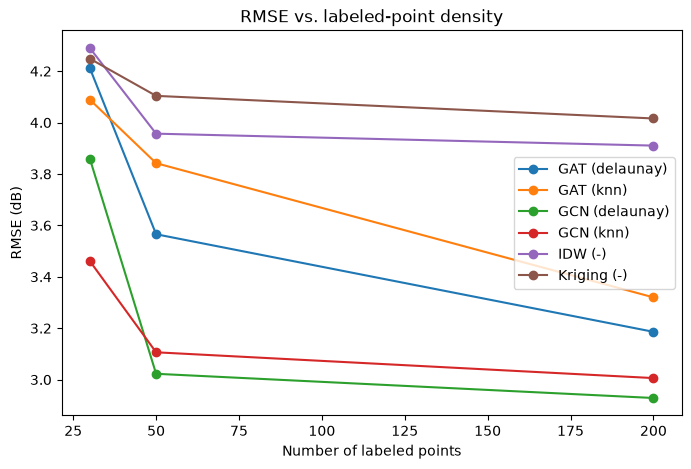

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(results)
display(df)

fig, ax = plt.subplots(figsize=(8, 5))
for (model, topo), grp in df.groupby(["model", "topology"]):
    grp = grp.sort_values("density")
    ax.plot(grp["density"], grp["rmse"], marker="o", label=f"{model} ({topo})")
ax.set_xlabel("Number of labeled points")
ax.set_ylabel("RMSE (dB)")
ax.set_title("RMSE vs. labeled-point density")
ax.legend()
plt.show()


### 6c. Coverage accuracy metric

RMSE measures magnitude error but says nothing about whether a point is
correctly classified as "covered" vs. "outage" at a given receiver
sensitivity -- the metric the timeline actually calls for alongside RMSE.


In [15]:
def coverage_accuracy(rss_true, rss_pred, threshold_dbm):
    """Binary covered/outage classification accuracy at a sensitivity
    threshold. Complements RMSE, which only measures magnitude error."""
    true_covered = rss_true > threshold_dbm
    pred_covered = rss_pred > threshold_dbm
    return float((true_covered == pred_covered).mean())


def pick_coverage_threshold(rss, percentile=50.0):
    """Data-driven sensitivity threshold. A fixed -90 dBm cutoff can sit
    entirely outside a scenario's actual RSS range (e.g. every point above
    it, or every point below it) -- when that happens, coverage_accuracy
    is degenerate: every model, including the baselines, trivially scores
    1.0 or 0.0 regardless of prediction quality, which is exactly what was
    happening (cov_mean pinned at 1.0/0.0 with cov_std 0.0 everywhere).
    Picking a percentile of the scenario's OBSERVED RSS distribution
    (median by default) guarantees the threshold actually splits the data,
    so the metric carries real discriminative information."""
    return float(np.percentile(rss, percentile))


def graph_topology_stats(edge_index, n_nodes):
    """Structural stats to help explain RMSE differences between kNN and
    Delaunay graphs (density/regularity of connectivity)."""
    deg = np.bincount(edge_index[0], minlength=n_nodes)
    return {
        "n_edges": edge_index.shape[1] // 2,
        "avg_degree": float(deg.mean()),
        "min_degree": int(deg.min()),
        "max_degree": int(deg.max()),
        "degree_std": float(deg.std()),
    }


### 6d. Full sweep across every scenario, with coverage accuracy

Extends `sweep()` to (a) run on every indoor scenario, not just
`SCENARIO_NAME`, and (b) record `coverage_acc` and topology structural
stats alongside `rmse` for every (scenario, density, topology, model)
combination.


In [16]:
def sweep_full(scenario_names=("i2_28b", "i1_2p5"), densities=(30, 50, 200),
               topologies=("knn", "delaunay"), n_seeds=3,
               coverage_threshold_dbm=None):
    all_results = []
    for scenario_name in scenario_names:
        positions, rss, feats, freq_ghz = load_scenario(scenario_name)

        # Data-driven coverage threshold (fix for the degenerate-metric
        # issue): pass coverage_threshold_dbm explicitly if you want a
        # fixed sensitivity across scenarios for a specific report claim;
        # otherwise each scenario gets its own median-RSS threshold so the
        # coverage metric always actually splits that scenario's data.
        if coverage_threshold_dbm is not None:
            thresh = coverage_threshold_dbm
        else:
            thresh = pick_coverage_threshold(rss, percentile=50.0)
        print(f"[{scenario_name}] coverage threshold: {thresh:.1f} dBm "
              f"(RSS range {rss.min():.1f} to {rss.max():.1f} dBm)")

        for n_labeled in densities:
            for seed in range(n_seeds):
                train_idx, test_idx = make_split(len(positions), n_labeled, seed=seed)

                for topo in topologies:
                    edge_index, edge_weight = BUILDERS[topo](positions)
                    topo_stats = graph_topology_stats(edge_index, len(positions))

                    for name, model_cls in [("GCN", GCN), ("GAT", GAT)]:
                        pred, rmse = run_gnn(model_cls, positions, feats, rss, freq_ghz,
                                          edge_index, train_idx, test_idx,
                                          edge_weight=edge_weight, seed=seed)
                        cov_acc = coverage_accuracy(rss[test_idx], pred[test_idx], thresh)
                        all_results.append({
                            "scenario": scenario_name, "density": n_labeled, "seed": seed,
                            "topology": topo, "model": name, "rmse": rmse, "coverage_acc": cov_acc,
                            **{f"topo_{k}": v for k, v in topo_stats.items()},
                        })

                idw_pred = idw_predict(positions[train_idx], rss[train_idx], positions[test_idx])
                all_results.append({
                    "scenario": scenario_name, "density": n_labeled, "seed": seed,
                    "topology": "-", "model": "IDW",
                    "rmse": float(np.sqrt(mean_squared_error(rss[test_idx], idw_pred))),
                    "coverage_acc": coverage_accuracy(rss[test_idx], idw_pred, thresh),
                })

                krig_pred = kriging_predict(positions[train_idx], rss[train_idx], positions[test_idx])
                all_results.append({
                    "scenario": scenario_name, "density": n_labeled, "seed": seed,
                    "topology": "-", "model": "Kriging",
                    "rmse": float(np.sqrt(mean_squared_error(rss[test_idx], krig_pred))),
                    "coverage_acc": coverage_accuracy(rss[test_idx], krig_pred, thresh),
                })
    return pd.DataFrame(all_results)


full_results = sweep_full()
summary = (full_results.groupby(["scenario", "density", "topology", "model"])
           .agg(rmse_mean=("rmse", "mean"), rmse_std=("rmse", "std"),
                cov_mean=("coverage_acc", "mean"), cov_std=("coverage_acc", "std"))
           .reset_index())
display(summary)


Scenario "i2_28b" already exists in /home/praaneshnair/gitProjects/prism/deepmimo_scenarios
Subsampled i2_28b: 140901 -> 5000 rx points (at load time).
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 5000)


Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 45.41it/s]


[load_scenario] i2_28b: 9 node features [dist_to_tx, los_flag, dx, dy, dz, path_count, delay_spread, azimuth, elevation]
[i2_28b] coverage threshold: -110.0 dBm (RSS range -135.1 to -100.4 dBm)
Scenario "i1_2p5" already exists in /home/praaneshnair/gitProjects/prism/deepmimo_scenarios
Subsampled i1_2p5: 80601 -> 5000 rx points (at load time).
Loading TXRX PAIR: TXset 2 (tx_idx 0) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 1) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 2) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 3) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 4) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 5) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 6) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 7) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 8) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 9) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 

Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:00<00:00, 1018.99it/s]

[load_scenario] i1_2p5: 9 node features [dist_to_tx, los_flag, dx, dy, dz, path_count, delay_spread, azimuth, elevation]
[i1_2p5] coverage threshold: -82.7 dBm (RSS range -89.0 to -78.5 dBm)


,scenario,density,topology,model,rmse_mean,rmse_std,cov_mean,cov_std
0,i1_2p5,30,-,IDW,1.116842,0.042341,0.826358,0.007319
1,i1_2p5,30,-,Kriging,1.176772,0.055891,0.815359,0.019659
2,i1_2p5,30,delaunay,GAT,1.526893,0.629549,0.807445,0.023284
3,i1_2p5,30,delaunay,GCN,1.266448,0.080468,0.811938,0.011098
4,i1_2p5,30,knn,GAT,1.157541,0.029178,0.807847,0.009714
5,i1_2p5,30,knn,GCN,1.287404,0.128833,0.797921,0.029023
6,i1_2p5,50,-,IDW,1.059688,0.042391,0.836835,0.003171
7,i1_2p5,50,-,Kriging,1.100988,0.043699,0.835825,0.012031
8,i1_2p5,50,delaunay,GAT,1.222265,0.078432,0.796700,0.026022
9,i1_2p5,50,delaunay,GCN,1.358344,0.054436,0.786061,0.044273


### 6e. Topology effect analysis

Quantifies the "kNN vs. Delaunay" comparison instead of leaving it as an
eyeballed guess: pivots RMSE by topology, holding scenario/density/model
fixed, so the size and direction of the topology effect is explicit.


In [17]:
def analyze_topology_effect(results_df):
    gnn_rows = results_df[results_df["topology"].isin(["knn", "delaunay"])]
    pivot = gnn_rows.pivot_table(index=["scenario", "density", "model"],
                                  columns="topology", values="rmse")
    pivot["delta_rmse (delaunay - knn)"] = pivot["delaunay"] - pivot["knn"]
    return pivot.sort_values("delta_rmse (delaunay - knn)")


analyze_topology_effect(full_results)


topology                delaunay       knn  delta_rmse (delaunay - knn)
scenario density model                                                 
i2_28b   50      GCN    3.182717  3.367287                    -0.184571
                 GAT    3.849864  3.994323                    -0.144459
         200     GCN    2.945223  3.085072                    -0.139850
         30      GCN    3.750041  3.821882                    -0.071841
i1_2p5   30      GCN    1.266448  1.287404                    -0.020956
i2_28b   200     GAT    3.227592  3.247942                    -0.020350
i1_2p5   50      GAT    1.222265  1.241063                    -0.018798
         200     GAT    1.094814  1.097952                    -0.003138
                 GCN    1.174180  1.133882                     0.040299
         50      GCN    1.358344  1.290284                     0.068060
         30      GAT    1.526893  1.157541                     0.369352
i2_28b   30      GAT    4.366965  3.902535                     0.464429

## 7. Generalization across indoor layouts

Train on one scenario, zero-shot evaluate on a different (unseen) layout.

### 7a. Two-way generalization sweep

Trains on one scenario and zero-shot evaluates on the other, in **both**
directions, across every topology/model combination, and reports coverage
accuracy alongside RMSE.

**Bug-fix pass:** normalization is now fit on the TRAIN scenario only and
the identical transform is applied to the TEST scenario, and predictions
are denormalized with those same TRAIN stats before computing RMSE/coverage.
The earlier version trained on each scenario's raw, unnormalized
coordinates/features, so at test time the model saw a scale its weights
were never trained on -- that's what produced RMSE of 30-100+ dB and
coverage_acc pinned at exactly 0.500 for every train/test combination.

**Second bug-fix pass:** even with normalization fixed, raw position was
still part of the model's input (`np.hstack([pos_n, feats_n])`). That's
especially damaging here: `i2_28b` and `i1_2p5` have different footprints,
so a normalized position that's well within range for the TRAIN building
can land anywhere -- including totally implausible spots -- once mapped
onto the TEST building's geometry, and the model has learned to associate
specific (now-meaningless) position values with specific RSS levels from
the TRAIN layout only. Position is now used solely to build `edge_index`
for each scenario; the model itself only ever sees `feats` (dist_to_tx,
los_flag), which *is* comparable across buildings, plus a clipping safety
net in `apply_normalizer` in case the TEST building's feature range (e.g.
a larger `dist_to_tx` in a bigger room) still exceeds what TRAIN showed it.


In [18]:
def full_generalization_sweep(scenario_pairs=(("i2_28b", "i1_2p5"), ("i1_2p5", "i2_28b")),
                               topologies=("knn", "delaunay"),
                               models=(("GCN", GCN), ("GAT", GAT)),
                               epochs=300, lr=0.01, n_seeds=3,
                               n_calib_points=10):
    """n_calib_points: size of the small labeled sample drawn from the
    TEST scenario to fit a few-shot calibration offset (fix for the
    cross-scenario calibration bug -- see fit_calibration_offset). These
    points are excluded from the reported RMSE/coverage_acc so the offset
    can't leak into the evaluation numbers."""
    results = []
    cache = {}

    def get(name):
        if name not in cache:
            cache[name] = load_scenario(name)
        return cache[name]

    for train_scenario, test_scenario in scenario_pairs:
        pos_tr, rss_tr, feat_tr, freq_tr = get(train_scenario)
        pos_te, rss_te, feat_te, freq_te = get(test_scenario)

        # Fit normalization on the TRAIN scenario only, then apply that
        # SAME transform to the test scenario. Model inputs are `feats`
        # only (dist_to_tx, los_flag) -- NOT raw position. Position is
        # only used below to build each scenario's own edge_index; it's
        # not a physically comparable quantity across two different
        # building footprints, so feeding it to the model would let it
        # memorize "where the strong-signal region is in the TRAIN
        # building" instead of learning a transferable distance/LOS ->
        # RSS relationship.
        stats = fit_normalizer(feat_tr, rss_tr, freq_tr)
        feat_tr_n, rss_tr_n = apply_normalizer(feat_tr, rss_tr, stats)
        # clip=8.0 (looser than the default 4.0) for TEST features: with
        # clip=4.0, i1_2p5's narrower TRAIN dist_to_tx range clipped ~73%
        # of i2_28b's TEST points to the same boundary value, destroying
        # the near/far distinction the model needs. 8.0 still guards
        # against genuine outliers but keeps more real spread when TEST
        # legitimately covers a wider range than TRAIN did.
        feat_te_n, _ = apply_normalizer(feat_te, rss_te, stats, clip=8.0)
        # --- diagnostic: is clipping collapsing TEST features to a constant? ---
        clip_rate = float(np.mean(np.abs(feat_te_n[:, 0]) >= 8.0 - 1e-6))
        print(f"[{train_scenario} -> {test_scenario}] dist_to_tx clip rate on TEST: "
              f"{clip_rate:.1%}  |  TRAIN range={feat_tr[:,0].min():.1f}-{feat_tr[:,0].max():.1f} m, "
              f"TEST range={feat_te[:,0].min():.1f}-{feat_te[:,0].max():.1f} m")

        # --- calibration diagnostic: absolute power level per scenario,
        # each computed with ITS OWN true carrier frequency. ---
        residual_summary(feat_tr, rss_tr, freq_tr, label=f"TRAIN={train_scenario}")
        residual_summary(feat_te, rss_te, freq_te, label=f"TEST={test_scenario} (full)")

        # --- few-shot recalibration: hold out a small labeled sample from
        # TEST to estimate this scenario's absolute calibration offset
        # (computed with TEST's own true freq_te -- see
        # fit_calibration_offset), then evaluate on the REMAINING test
        # points only, so the calibration points can't leak into the
        # reported metrics. ---
        rng_calib = np.random.default_rng(0)
        n_te = len(rss_te)
        n_calib = min(n_calib_points, max(1, n_te // 10))
        calib_perm = rng_calib.permutation(n_te)
        calib_idx, eval_idx = calib_perm[:n_calib], calib_perm[n_calib:]
        calib_offset = fit_calibration_offset(feat_te[calib_idx], rss_te[calib_idx], freq_te, stats)
        print(f"[{train_scenario} -> {test_scenario}] few-shot calibration offset "
              f"from {n_calib} TEST points: {calib_offset:+.2f} dB")

        rss_te_eval = rss_te[eval_idx]
        feat_te_eval = feat_te[eval_idx]
        pos_te_eval = pos_te[eval_idx]
        feat_te_n_eval = feat_te_n[eval_idx]

        thresh_te = pick_coverage_threshold(rss_te_eval, percentile=50.0)
        print(f"[{test_scenario}] coverage threshold (eval split): {thresh_te:.1f} dBm "
              f"(RSS range {rss_te_eval.min():.1f} to {rss_te_eval.max():.1f} dBm)")

        x_tr = torch.tensor(feat_tr_n, dtype=torch.float32)
        y_tr = torch.tensor(rss_tr_n, dtype=torch.float32).unsqueeze(1)
        x_te = torch.tensor(feat_te_n_eval, dtype=torch.float32)

        for topo in topologies:
            ei_tr_np, ew_tr_np = BUILDERS[topo](pos_tr)
            ei_te_np, ew_te_np = BUILDERS[topo](pos_te_eval)
            ei_tr = torch.tensor(ei_tr_np, dtype=torch.long)
            ei_te = torch.tensor(ei_te_np, dtype=torch.long)
            ew_tr = torch.tensor(ew_tr_np, dtype=torch.float32)
            ew_te = torch.tensor(ew_te_np, dtype=torch.float32)

            for name, model_cls in models:
                for seed in range(n_seeds):
                    rng = np.random.default_rng(seed)
                    n_tr = len(rss_tr)
                    perm = rng.permutation(n_tr)
                    n_val = max(1, int(n_tr * 0.15))
                    val_idx, fit_idx = perm[:n_val], perm[n_val:]
                    train_mask = torch.zeros(n_tr, dtype=torch.bool)
                    train_mask[fit_idx] = True
                    val_mask = torch.zeros(n_tr, dtype=torch.bool)
                    val_mask[val_idx] = True

                    model = model_cls(in_channels=x_tr.shape[1])
                    model = _train_gnn(model, x_tr, ei_tr, y_tr, train_mask, val_mask,
                                        edge_weight=ew_tr, epochs=epochs, lr=lr, weight_decay=1e-4,
                                        patience=30, seed=seed)

                    with torch.no_grad():
                        pred_te_n = model(x_te, ei_te, edge_weight=ew_te).numpy().squeeze()
                    # THE fix: reconstruct with TEST's own true freq_te
                    # (not stats["freq_ghz"], which is TRAIN's frequency)
                    # PLUS the few-shot calibration offset. Using the
                    # wrong frequency here was the source of the ~21-24 dB
                    # of RMSE that remained even after the calibration-
                    # offset fix -- see denormalize_rss's docstring.
                    pred_te = denormalize_rss(pred_te_n, stats, feat_te_eval[:, 0],
                                               freq_ghz=freq_te, calib_offset_db=calib_offset)

                    rmse = float(np.sqrt(mean_squared_error(rss_te_eval, pred_te)))
                    cov_acc = coverage_accuracy(rss_te_eval, pred_te, thresh_te)
                    results.append({"train": train_scenario, "test": test_scenario,
                                     "topology": topo, "model": name, "seed": seed,
                                     "n_calib_points": n_calib, "calib_offset_db": calib_offset,
                                     "rmse": rmse, "coverage_acc": cov_acc})
                    print(f"[{name}/{topo} seed={seed}] {train_scenario} -> {test_scenario}: "
                          f"RMSE={rmse:.3f} dB, coverage_acc={cov_acc:.3f}")
    return pd.DataFrame(results)


generalization_results = full_generalization_sweep()
gen_summary = (generalization_results
               .groupby(["train", "test", "topology", "model"])
               .agg(rmse_mean=("rmse", "mean"), rmse_std=("rmse", "std"),
                    cov_mean=("coverage_acc", "mean"), cov_std=("coverage_acc", "std"))
               .reset_index())
display(gen_summary)


Scenario "i2_28b" already exists in /home/praaneshnair/gitProjects/prism/deepmimo_scenarios
Subsampled i2_28b: 140901 -> 5000 rx points (at load time).
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 5000)


Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 47.38it/s]


[load_scenario] i2_28b: 9 node features [dist_to_tx, los_flag, dx, dy, dz, path_count, delay_spread, azimuth, elevation]
Scenario "i1_2p5" already exists in /home/praaneshnair/gitProjects/prism/deepmimo_scenarios
Subsampled i1_2p5: 80601 -> 5000 rx points (at load time).
Loading TXRX PAIR: TXset 2 (tx_idx 0) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 1) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 2) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 3) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 4) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 5) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 6) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 7) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 8) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 9) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 10) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx

Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:00<00:00, 1036.21it/s]


[load_scenario] i1_2p5: 9 node features [dist_to_tx, los_flag, dx, dy, dz, path_count, delay_spread, azimuth, elevation]
[warn] apply_normalizer: 45.5% of values exceed clip=8.0 std -- TRAIN stats may not cover this data's range.
[i2_28b -> i1_2p5] dist_to_tx clip rate on TEST: 0.0%  |  TRAIN range=5.6-12.6 m, TEST range=5.2-8.3 m
[calib] TRAIN=i2_28b residual (rss - fspl): mean=-190.70 dB, std=4.08 dB, n=5000
[calib] TEST=i1_2p5 (full) residual (rss - fspl): mean=-139.62 dB, std=2.44 dB, n=5000
[i2_28b -> i1_2p5] few-shot calibration offset from 10 TEST points: +51.90 dB
[i1_2p5] coverage threshold (eval split): -82.7 dBm (RSS range -89.0 to -78.5 dBm)
[GCN/knn seed=0] i2_28b -> i1_2p5: RMSE=4.706 dB, coverage_acc=0.500
[GCN/knn seed=1] i2_28b -> i1_2p5: RMSE=5.156 dB, coverage_acc=0.500
[GCN/knn seed=2] i2_28b -> i1_2p5: RMSE=3.056 dB, coverage_acc=0.371
[GAT/knn seed=0] i2_28b -> i1_2p5: RMSE=5.292 dB, coverage_acc=0.500
[GAT/knn seed=1] i2_28b -> i1_2p5: RMSE=6.681 dB, coverage_acc

,train,test,topology,model,rmse_mean,rmse_std,cov_mean,cov_std
0,i1_2p5,i2_28b,delaunay,GAT,5.918421,1.008385,0.500000,0.000000
1,i1_2p5,i2_28b,delaunay,GCN,5.807007,0.644333,0.500000,0.000000
2,i1_2p5,i2_28b,knn,GAT,5.711800,0.216756,0.500000,0.000000
3,i1_2p5,i2_28b,knn,GCN,7.643746,2.333783,0.500000,0.000000
4,i2_28b,i1_2p5,delaunay,GAT,6.937296,2.877190,0.499466,0.000926
5,i2_28b,i1_2p5,delaunay,GCN,5.277725,1.010281,0.500000,0.000000
6,i2_28b,i1_2p5,knn,GAT,6.360266,0.949782,0.500000,0.000000
7,i2_28b,i1_2p5,knn,GCN,4.306053,1.105339,0.457114,0.074280


## 8. Sparse Regime Benchmark — M3 Deliverable

**Goal:** Quantify GNN advantage over classical methods (IDW/Kriging) when measurement data is scarce.

**Hypothesis:** At n=30–50 points, GCN/GAT will show 10–30% lower RMSE than IDW/Kriging, with the gap narrowing at higher densities.

This is critical for the M3→M4 report: shows where GNN adds *practical* value.

### 8a. Hybrid GNN + IDW residual model

Adds a third GNN variant that learns a *residual correction on top of an
IDW prior* instead of learning RSS from scratch: `pred = idw_pred +
GNN(features)`. The idea is that IDW already captures the smooth,
distance-driven part of the radio map, so the GNN only has to learn the
harder, structure-dependent leftover (multipath, LOS/NLOS transitions,
etc.), which is a smaller target to fit at low measurement density.

Reuses the same z-scored features and kNN edge weights as GCN/GAT above
for a fair comparison, and uses **leave-one-out IDW** (`idw_predict_loo`)
to build the training target -- using each training point's own value as
part of its own IDW "prediction" would make the training-time residual
collapse to ~0 everywhere, which doesn't match the real (nonzero) residual
the model has to produce at test time.

In [19]:
# ============================================================
# Hybrid GNN + IDW residual model
# ============================================================
# Learns a GNN correction on top of a smooth IDW geostatistical prior:
#   pred = idw_pred + GNN(features)
# Uses the SAME feature z-scoring / edge-weight plumbing as the plain
# GCN/GAT path above (run_gnn) so the comparison is apples-to-apples, but
# the regression TARGET is the IDW residual (rss - idw_pred) rather than
# the FSPL residual fit_normalizer uses for GCN/GAT.

class HybridResidualGNN(nn.Module):
    """Hybrid model: learns a residual (RSS - IDW_prediction) with a GNN.
    Combines a smooth geostatistical prior (IDW) with a learned,
    graph-aware correction."""

    def __init__(self, in_channels, hidden_channels=32, out_channels=1,
                 dropout=0.3, use_gat=False, heads=4):
        super().__init__()
        self.use_gat = use_gat
        self.dropout = dropout

        if use_gat:
            self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
            self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, dropout=dropout)
        else:
            self.conv1 = GCNConv(in_channels, hidden_channels)
            self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index, edge_weight=None, idw_pred=None):
        """
        x: node features (N, in_channels), already z-scored by the caller
        edge_index: graph connectivity
        edge_weight: optional (num_edges,) kNN/Delaunay distance weight --
            used for GCNConv, ignored for GATConv (see GAT.forward above)
        idw_pred: IDW predictions (N,) -- if provided, the model's own
            output is added on top as a learned residual correction
        """
        if self.use_gat:
            h = self.conv1(x, edge_index)
        else:
            h = self.conv1(x, edge_index, edge_weight=edge_weight)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        if self.use_gat:
            residual = self.conv2(h, edge_index).squeeze(-1)
        else:
            residual = self.conv2(h, edge_index, edge_weight=edge_weight).squeeze(-1)

        if idw_pred is not None:
            return idw_pred + residual
        return residual


def run_hybrid_gnn(positions, feats, rss, edge_index, edge_weight, train_idx, test_idx,
                    epochs=300, lr=0.01, weight_decay=1e-4, val_frac=0.15, patience=30,
                    device="cpu", seed=0, use_gat=False, hidden=32, dropout=0.3):
    """Analogous to run_gnn() above, but for HybridResidualGNN: z-scores the
    raw features on TRAIN stats (fixing the same unnormalized-feature
    convergence problem the '## Bug-fix pass' note flags for plain GCN/GAT)
    and trains the GNN to predict the IDW residual rather than the FSPL
    residual fit_normalizer builds."""
    torch.manual_seed(seed)

    feats_mean = feats[train_idx].mean(0)
    feats_std = feats[train_idx].std(0) + 1e-8
    feats_n = np.clip((feats - feats_mean) / feats_std, -4.0, 4.0)

    # Leave-one-out IDW target for TRAIN points (no self-leak), plain IDW
    # for TEST points (no leak there either -- disjoint from train).
    idw_train = idw_predict_loo(positions[train_idx], rss[train_idx])
    idw_test = idw_predict(positions[train_idx], rss[train_idx], positions[test_idx])
    idw_full = np.zeros(len(positions))
    idw_full[train_idx] = idw_train
    idw_full[test_idx] = idw_test

    x = torch.tensor(feats_n, dtype=torch.float32).to(device)
    y = torch.tensor(rss, dtype=torch.float32).to(device)
    idw_t = torch.tensor(idw_full, dtype=torch.float32).to(device)
    ei = torch.tensor(edge_index, dtype=torch.long).to(device)
    ew = torch.tensor(edge_weight, dtype=torch.float32).to(device) if edge_weight is not None else None

    rng = np.random.default_rng(seed)
    perm = rng.permutation(train_idx)
    n_val = max(1, int(len(perm) * val_frac))
    val_idx, fit_idx = perm[:n_val], perm[n_val:]
    train_mask = torch.zeros(len(rss), dtype=torch.bool)
    train_mask[fit_idx] = True
    val_mask = torch.zeros(len(rss), dtype=torch.bool)
    val_mask[val_idx] = True
    train_mask, val_mask = train_mask.to(device), val_mask.to(device)

    model = HybridResidualGNN(in_channels=x.shape[1], hidden_channels=hidden,
                               dropout=dropout, use_gat=use_gat).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    best_val = float("inf")
    best_state = None
    epochs_since_best = 0

    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        out = model(x, ei, edge_weight=ew, idw_pred=idw_t)
        loss = loss_fn(out[train_mask], y[train_mask])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        opt.step()

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(x, ei, edge_weight=ew, idw_pred=idw_t)[val_mask], y[val_mask]).item()

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_since_best = 0
        else:
            epochs_since_best += 1
            if epochs_since_best >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()

    with torch.no_grad():
        pred = model(x, ei, edge_weight=ew, idw_pred=idw_t).cpu().numpy()

    rmse = float(np.sqrt(mean_squared_error(rss[test_idx], pred[test_idx])))
    return pred, rmse


In [20]:
# ============================================================
# Sparse Regime Sweep: GCN, GAT, Hybrid-GNN-IDW vs. IDW, Kriging
# Train/test on SAME scenario
# Varying measurement density from 30 to 200 points
# ============================================================

def sparse_density_sweep(
    scenario_names=("i2_28b", "i1_2p5"),
    densities=(30, 50, 100, 200),
    n_seeds=3
):
    """
    In-domain sweep at low measurement densities.

    Compares:
        - GCN
        - GAT
        - Hybrid-GNN-IDW
        - IDW
        - Kriging

    on the SAME scenario while varying the number of
    labeled/training points.
    """

    results = []

    for scenario_name in scenario_names:

        # ----------------------------------------------------
        # Load scenario
        # ----------------------------------------------------
        positions, rss, feats, freq_ghz = load_scenario(scenario_name)

        print("\n" + "=" * 80)
        print(f"Sparse Regime: {scenario_name}")
        print("=" * 80)

        # Coverage threshold based on median RSS
        thresh = pick_coverage_threshold(
            rss,
            percentile=50.0
        )

        # ----------------------------------------------------
        # Sweep measurement densities
        # ----------------------------------------------------
        for n_labeled in densities:

            rmse_by_method = {
                "GCN": [],
                "GAT": [],
                "Hybrid-GNN-IDW": [],
                "IDW": [],
                "Kriging": []
            }

            cov_by_method = {
                "GCN": [],
                "GAT": [],
                "Hybrid-GNN-IDW": [],
                "IDW": [],
                "Kriging": []
            }

            # ------------------------------------------------
            # Multiple random seeds
            # ------------------------------------------------
            for seed in range(n_seeds):

                train_idx, test_idx = make_split(
                    len(positions),
                    n_labeled,
                    seed=seed
                )

                # Build KNN graph (edge_index + distance-based edge_weight)
                edge_index_knn, edge_weight_knn = BUILDERS["knn"](positions)

                # ====================================================
                # GCN
                # ====================================================
                pred_gcn, rmse_gcn = run_gnn(
                    GCN,
                    positions,
                    feats,
                    rss,
                    freq_ghz,
                    edge_index_knn,
                    train_idx,
                    test_idx,
                    edge_weight=edge_weight_knn,
                    epochs=300,
                    seed=seed
                )

                cov_gcn = coverage_accuracy(
                    rss[test_idx],
                    pred_gcn[test_idx],
                    thresh
                )

                rmse_by_method["GCN"].append(rmse_gcn)
                cov_by_method["GCN"].append(cov_gcn)

                # ====================================================
                # GAT
                # ====================================================
                pred_gat, rmse_gat = run_gnn(
                    GAT,
                    positions,
                    feats,
                    rss,
                    freq_ghz,
                    edge_index_knn,
                    train_idx,
                    test_idx,
                    edge_weight=edge_weight_knn,
                    epochs=300,
                    seed=seed
                )

                cov_gat = coverage_accuracy(
                    rss[test_idx],
                    pred_gat[test_idx],
                    thresh
                )

                rmse_by_method["GAT"].append(rmse_gat)
                cov_by_method["GAT"].append(cov_gat)

                # ====================================================
                # Hybrid GNN + IDW residual
                # ====================================================
                pred_hybrid, rmse_hybrid = run_hybrid_gnn(
                    positions,
                    feats,
                    rss,
                    edge_index_knn,
                    edge_weight_knn,
                    train_idx,
                    test_idx,
                    epochs=300,
                    seed=seed
                )

                cov_hybrid = coverage_accuracy(
                    rss[test_idx],
                    pred_hybrid[test_idx],
                    thresh
                )

                rmse_by_method["Hybrid-GNN-IDW"].append(rmse_hybrid)
                cov_by_method["Hybrid-GNN-IDW"].append(cov_hybrid)

                # ====================================================
                # IDW
                # ====================================================
                pred_idw = idw_predict(
                    positions[train_idx],
                    rss[train_idx],
                    positions[test_idx],
                    power=2
                )

                rmse_idw = np.sqrt(
                    mean_squared_error(
                        rss[test_idx],
                        pred_idw
                    )
                )

                cov_idw = coverage_accuracy(
                    rss[test_idx],
                    pred_idw,
                    thresh
                )

                rmse_by_method["IDW"].append(rmse_idw)
                cov_by_method["IDW"].append(cov_idw)

                # ====================================================
                # Kriging
                # ====================================================
                try:
                    pred_kriging = kriging_predict(
                        positions[train_idx],
                        rss[train_idx],
                        positions[test_idx]
                    )

                    rmse_kriging = np.sqrt(
                        mean_squared_error(
                            rss[test_idx],
                            pred_kriging
                        )
                    )

                    cov_kriging = coverage_accuracy(
                        rss[test_idx],
                        pred_kriging,
                        thresh
                    )

                except Exception as e:
                    print(
                        f"[Kriging warning at seed {seed}] "
                        f"{type(e).__name__}: {e}"
                    )

                    rmse_kriging = np.nan
                    cov_kriging = np.nan

                rmse_by_method["Kriging"].append(rmse_kriging)
                cov_by_method["Kriging"].append(cov_kriging)

            # ====================================================
            # Print summary for this density
            # ====================================================
            print(f"\n  Density: {n_labeled} points")

            for method in [
                "GCN",
                "GAT",
                "Hybrid-GNN-IDW",
                "IDW",
                "Kriging"
            ]:

                rmse_vals = np.array(
                    rmse_by_method[method]
                )

                cov_vals = np.array(
                    cov_by_method[method]
                )

                rmse_mean = np.nanmean(rmse_vals)
                rmse_std = np.nanstd(rmse_vals)

                cov_mean = np.nanmean(cov_vals)
                cov_std = np.nanstd(cov_vals)

                print(
                    f"    {method:16s}: "
                    f"RMSE={rmse_mean:6.2f}\u00b1{rmse_std:.2f} dB, "
                    f"cov_acc={cov_mean:.3f}\u00b1{cov_std:.3f}"
                )

                # Store results
                results.append({
                    "scenario": scenario_name,
                    "method": method,
                    "n_labeled": n_labeled,
                    "rmse_mean": rmse_mean,
                    "rmse_std": rmse_std,
                    "cov_acc_mean": cov_mean,
                    "cov_acc_std": cov_std
                })

    return pd.DataFrame(results)


# ============================================================
# RUN SPARSE REGIME SWEEP
# ============================================================

print(
    "[RUNNING] Sparse regime sweep "
    "(may take 5\u201310 min on CPU)..."
)

sparse_results_df = sparse_density_sweep()


# ============================================================
# SUMMARY TABLES
# ============================================================

print("\n" + "=" * 80)
print("SPARSE REGIME SUMMARY TABLE (In-Domain)")
print("=" * 80)


# ------------------------------------------------------------
# RMSE Pivot Table
# ------------------------------------------------------------

rmse_pivot = sparse_results_df.pivot_table(
    values="rmse_mean",
    index=["scenario", "n_labeled"],
    columns="method"
)

print("\nRMSE (dB) \u2014 Lower is better:")
print(rmse_pivot.round(2))


# ------------------------------------------------------------
# Coverage Accuracy Pivot Table
# ------------------------------------------------------------

cov_pivot = sparse_results_df.pivot_table(
    values="cov_acc_mean",
    index=["scenario", "n_labeled"],
    columns="method"
)

print("\nCoverage Accuracy \u2014 Higher is better:")
print(cov_pivot.round(3))


# ============================================================
# GCN IMPROVEMENT OVER IDW
# ============================================================

print("\n" + "=" * 80)
print("GCN Improvement over IDW baseline (at each density)")
print("=" * 80)

for scenario in ["i2_28b", "i1_2p5"]:

    print(f"\n{scenario}:")

    for density in [30, 50, 100, 200]:

        subset = sparse_results_df[
            (sparse_results_df["scenario"] == scenario)
            & (sparse_results_df["n_labeled"] == density)
        ]

        gcn_rmse = subset[
            subset["method"] == "GCN"
        ]["rmse_mean"].values

        idw_rmse = subset[
            subset["method"] == "IDW"
        ]["rmse_mean"].values

        if len(gcn_rmse) > 0 and len(idw_rmse) > 0:

            improvement = (
                (idw_rmse[0] - gcn_rmse[0])
                / idw_rmse[0]
                * 100
            )

            print(
                f"  n={density:3d}: "
                f"GCN is {improvement:+.1f}% vs IDW"
            )


[RUNNING] Sparse regime sweep (may take 5–10 min on CPU)...
Scenario "i2_28b" already exists in /home/praaneshnair/gitProjects/prism/deepmimo_scenarios
Subsampled i2_28b: 140901 -> 5000 rx points (at load time).
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 5000)


Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 46.93it/s]


[load_scenario] i2_28b: 9 node features [dist_to_tx, los_flag, dx, dy, dz, path_count, delay_spread, azimuth, elevation]

Sparse Regime: i2_28b

  Density: 30 points
    GCN             : RMSE=  3.75±0.13 dB, cov_acc=0.636±0.051
    GAT             : RMSE=  3.85±0.27 dB, cov_acc=0.644±0.025
    Hybrid-GNN-IDW  : RMSE=  3.90±0.56 dB, cov_acc=0.644±0.052
    IDW             : RMSE=  4.42±0.15 dB, cov_acc=0.589±0.021
    Kriging         : RMSE=  4.32±0.14 dB, cov_acc=0.596±0.018

  Density: 50 points
    GCN             : RMSE=  3.33±0.24 dB, cov_acc=0.665±0.067
    GAT             : RMSE=  4.01±0.19 dB, cov_acc=0.577±0.044
    Hybrid-GNN-IDW  : RMSE=  3.97±0.48 dB, cov_acc=0.604±0.058
    IDW             : RMSE=  4.28±0.24 dB, cov_acc=0.578±0.020
    Kriging         : RMSE=  4.27±0.17 dB, cov_acc=0.593±0.033

  Density: 100 points
    GCN             : RMSE=  3.11±0.15 dB, cov_acc=0.727±0.010
    GAT             : RMSE=  3.71±0.20 dB, cov_acc=0.625±0.031
    Hybrid-GNN-IDW  : RMSE=  3.38

Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:00<00:00, 1050.60it/s]

[load_scenario] i1_2p5: 9 node features [dist_to_tx, los_flag, dx, dy, dz, path_count, delay_spread, azimuth, elevation]

Sparse Regime: i1_2p5



  Density: 30 points
    GCN             : RMSE=  1.25±0.06 dB, cov_acc=0.818±0.007
    GAT             : RMSE=  1.40±0.31 dB, cov_acc=0.819±0.003
    Hybrid-GNN-IDW  : RMSE=  1.11±0.01 dB, cov_acc=0.833±0.003
    IDW             : RMSE=  1.12±0.03 dB, cov_acc=0.826±0.006
    Kriging         : RMSE=  1.18±0.05 dB, cov_acc=0.815±0.016

  Density: 50 points
    GCN             : RMSE=  1.28±0.13 dB, cov_acc=0.804±0.026
    GAT             : RMSE=  1.23±0.04 dB, cov_acc=0.780±0.020
    Hybrid-GNN-IDW  : RMSE=  1.05±0.01 dB, cov_acc=0.841±0.013
    IDW             : RMSE=  1.06±0.03 dB, cov_acc=0.837±0.003
    Kriging         : RMSE=  1.10±0.04 dB, cov_acc=0.836±0.010

  Density: 100 points
    GCN             : RMSE=  1.19±0.02 dB, cov_acc=0.812±0.014
    GAT             : RMSE=  1.17±0.04 dB, cov_acc=0.797±0.023
    Hybrid-GNN-IDW  : RMSE=  0.98±0.01 dB, cov_acc=0.838±0.003
    IDW             : RMSE=  0.96±0.05 dB, cov_acc=0.849±0.004
    Kriging         : RMSE=  0.99±0.06 dB, cov_acc=

## 9. Query-conditioned star-graph model (SeaGAT-inspired)

Adds `EdgeAwareStarGAT` alongside the GCN/GAT/Hybrid/IDW/Kriging comparison above (which is left intact).
Unlike the whole-scenario GCN/GAT, each query is answered from a bounded set of **K nearby reference
measurements** (their observed RSS is an input), connected to the target by a directed star. Edge features
(distance, bearing, LOS agreement) only shape the attention score; only node evidence is transferred.

Evaluation follows the paper's leave-one-out protocol: the labeled pool is both the reference set and the
training-query set (a query never sees its own RSS), and held-out points are answered against the same pool.

Requires cells from sections 2, 4 and 6 (`load_scenario`, `fit_normalizer`, `make_split`, `mean_squared_error`, `pd`/`plt`) to have been run.

**Update:** the first run showed `EdgeAwareStarGAT` (v1) at ~4.1 dB RMSE regardless of density, K or sampling -- about the residual std of a constant predictor. 9d compares constant floors, IDW, v1 and v2 on identical pools before the sampling / K sweeps are trusted.

### 9a. Star-batch builder, `EdgeAwareStarGAT` (v1) and `EdgeAwareStarGATv2`

v1 is kept unchanged for comparison. v2 adds target-conditioned attention, an evidence-anchored output (attention-weighted reference RSS + zero-initialised correction), and a learnable distance prior.

In [21]:
# ============================================================
# Query-conditioned target-centered star graph (SeaGAT-inspired)
# ============================================================
# This section does NOT replace the GCN/GAT/IDW/Kriging comparison above --
# M3 explicitly requires that comparison, so it stays intact. This adds a
# genuinely different graph formulation the PDF (use_pdf.md) flagged as the
# biggest structural gap: the existing GCN/GAT run message passing over one
# whole-scenario spatial graph, with the label (RSS) never appearing as an
# input feature anywhere. SeaGAT instead answers each query
# "what RSS would target t see from tx b?" from a BOUNDED, per-query set of
# K nearby REFERENCE MEASUREMENTS (whose actual observed RSS values ARE an
# input), connected to the target by a directed star (references -> target)
# rather than a shared spatial graph. That is the "evidence transfer" framing
# from the paper's Eq. (2)-(7), and it is a different question from "smooth
# a field over a graph."
#
# Kept faithful to the paper, scaled to this dataset:
#   - node features per reference r: transmitter-centered relative position
#     p_r - p_b (dx,dy,dz) and the reference's OWN observed RSS  (Eq. 8)
#   - edge features per (r, t): target-reference distance and bearing
#     (Eq. 9), plus a LOS/NLOS link-state agreement category (Eq. 10),
#     since this dataset's `los_flag` already gives us that for free
#   - attention scores mix node+edge info; only node-derived messages are
#     summed into the target's aggregate (Eq. 24-27) -- edges never inject
#     content, only relevance
#   - reference set per query = K-nearest neighbours from a bounded
#     REFERENCE POOL, with the query point excluded from its own pool
#     (leave-one-out, Sec. IV-B of the paper) so a training query is never
#     allowed to see its own true RSS as "evidence"

from scipy.spatial import cKDTree


def build_star_batch(query_idx, ref_pool_idx, positions, feats, rss_n, tx_pos, K):
    """Vectorized target-centered star-graph batch builder.

    query_idx     : indices of the points being predicted (targets)
    ref_pool_idx  : indices allowed to act as REFERENCES (measurement pool)
    positions     : (N,3) all point positions
    feats         : (N,F) node/env features; column 0 = dist_to_tx,
                    column 1 = los_flag (see load_scenario's column-order note)
    rss_n         : (N,) NORMALIZED rss (same scale the GNNs regress on),
                    used as the reference-side "observed evidence"
    tx_pos        : (3,) transmitter position
    K             : number of references sampled per query

    Returns dict of numpy arrays, each leading-dim = len(query_idx):
      node_feat   (B,K,4)  -> [dx,dy,dz to tx, ref rss_n]   (Eq. 8)
      edge_feat   (B,K,4)  -> [dist, sin(bearing), cos(bearing), los_agree]
      valid_mask  (B,K)    -> False for padding when a query has <K
                              eligible references (small ref pools)
      target_rss_n(B,)     -> ground-truth normalized RSS for the target
      query_feat  (B,5)    -> RAW target features [dist_to_tx, los, dx, dy, dz]
                              (used by EdgeAwareStarGATv2 only; v1 ignores it)
    """
    ref_pos = positions[ref_pool_idx]
    ref_rss_n = rss_n[ref_pool_idx]
    ref_los = feats[ref_pool_idx, 1]
    ref_rel = ref_pos - tx_pos[None, :]

    tree = cKDTree(ref_pos[:, :2])  # bearing/distance are 2D (x,y) as in the paper
    q_pos = positions[query_idx]
    q_los = feats[query_idx, 1]

    # query K+1 in case the query itself is inside the reference pool
    kq = min(K + 1, len(ref_pool_idx))
    dists, nn_idx = tree.query(q_pos[:, :2], k=kq)
    if kq == 1:  # cKDTree squeezes the last dim when k == 1
        dists, nn_idx = dists[:, None], nn_idx[:, None]

    B = len(query_idx)
    node_feat = np.zeros((B, K, 4), dtype=np.float32)
    edge_feat = np.zeros((B, K, 4), dtype=np.float32)
    valid_mask = np.zeros((B, K), dtype=bool)

    ref_pool_set_pos_key = {idx: j for j, idx in enumerate(ref_pool_idx)}
    for b, qi in enumerate(query_idx):
        cand_cols = nn_idx[b]
        cand_dists = dists[b]
        # drop the query itself if it shows up in its own reference pool
        keep = np.array([ref_pool_idx[c] != qi for c in cand_cols])
        cand_cols = cand_cols[keep][:K]
        cand_dists = cand_dists[keep][:K]
        n_valid = len(cand_cols)
        valid_mask[b, :n_valid] = True

        rel = ref_rel[cand_cols]                      # (n_valid,3)
        node_feat[b, :n_valid, 0:3] = rel
        node_feat[b, :n_valid, 3] = ref_rss_n[cand_cols]

        dxy = ref_pos[cand_cols, :2] - q_pos[b, :2][None, :]
        bearing = np.arctan2(dxy[:, 1], dxy[:, 0])
        edge_feat[b, :n_valid, 0] = cand_dists
        edge_feat[b, :n_valid, 1] = np.sin(bearing)
        edge_feat[b, :n_valid, 2] = np.cos(bearing)
        # LOS agreement: +1 if target/ref links agree (both LOS or both
        # NLOS), -1 if they disagree -- a compact stand-in for the paper's
        # 4-way {LL,NN,LN,NL} categorical, cheap enough to leave continuous
        agree = np.where(ref_los[cand_cols] == q_los[b], 1.0, -1.0)
        edge_feat[b, :n_valid, 3] = agree

    return {
        "node_feat": node_feat, "edge_feat": edge_feat, "valid_mask": valid_mask,
        "target_rss_n": rss_n[query_idx].astype(np.float32),
        "query_feat": feats[query_idx, 0:5].astype(np.float32),
    }


class EdgeAwareStarGAT(nn.Module):
    """Bounded target-centered star-graph attention model (Sec. III of the
    paper, scaled down). Node representations carry measurement evidence;
    edge representations carry the query-reference geometric relation and
    enter ONLY the attention score, never the transferred message -- the
    same node/edge separation the PDF's ablation (Table I) shows is the
    single biggest contributor to accuracy (uniform attention costs
    +1.58 to +2.14 dB RMSE in the paper's own ablation)."""

    def __init__(self, node_dim=4, edge_dim=4, hidden=32, dropout=0.2):
        super().__init__()
        self.node_enc = nn.Sequential(nn.Linear(node_dim, hidden), nn.ReLU())
        self.edge_enc = nn.Sequential(nn.Linear(edge_dim, hidden), nn.ReLU())
        self.attn = nn.Linear(2 * hidden, 1)
        self.msg = nn.Linear(hidden, hidden)
        self.readout = nn.Sequential(
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden, 1)
        )

    def forward(self, node_feat, edge_feat, valid_mask, query_feat=None, return_attn=False):
        # node_feat/edge_feat: (B,K,*), valid_mask: (B,K) bool; query_feat unused in v1
        h = self.node_enc(node_feat)          # (B,K,E)
        e = self.edge_enc(edge_feat)          # (B,K,E)
        score = self.attn(torch.cat([h, e], dim=-1)).squeeze(-1)   # (B,K)  Eq.(24)
        score = F.leaky_relu(score, negative_slope=0.1)
        score = score.masked_fill(~valid_mask, float("-inf"))
        alpha = torch.softmax(score, dim=-1)                        # Eq.(25)
        alpha = torch.nan_to_num(alpha, nan=0.0)  # rows with 0 valid refs (shouldn't happen, but safe)
        m = self.msg(h)                                             # Eq.(26), node-only message
        agg = torch.einsum("bk,bke->be", alpha, m)                  # Eq.(27)
        pred = self.readout(torch.tanh(agg)).squeeze(-1)            # Eq.(28)-(29)
        if return_attn:
            return pred, alpha
        return pred


class EdgeAwareStarGATv2(nn.Module):
    """Fixed version of EdgeAwareStarGAT. Changes vs. v1 (each targets a
    suspected reason v1 collapsed to a ~constant, FSPL-only prediction):
      1. QUERY-CONDITIONED: the target's own tx-relative features
         (dist_to_tx, los, dx, dy, dz) are encoded and fed into the attention
         score and the readout -- v1 never saw them.
      2. EVIDENCE-ANCHORED OUTPUT: pred = sum_k alpha_k * ref_rss_n_k + correction,
         with the correction head zero-initialised. At step 0 the model is
         already an attention-weighted neighbour average (IDW-like) and can only
         improve on it, instead of having to rediscover 'copy the neighbours'
         through a tanh bottleneck.
      3. LEARNABLE DISTANCE PRIOR: score -= softplus(w) * normalised_distance,
         an IDW-style inductive bias (edges still only affect relevance).
    Inputs are expected z-scored (see _normalize_star_batch)."""

    def __init__(self, node_dim=4, edge_dim=4, query_dim=5, hidden=32, dropout=0.1):
        super().__init__()
        self.node_enc = nn.Sequential(nn.Linear(node_dim, hidden), nn.ReLU())
        self.edge_enc = nn.Sequential(nn.Linear(edge_dim, hidden), nn.ReLU())
        self.query_enc = nn.Sequential(nn.Linear(query_dim, hidden), nn.ReLU())
        self.attn = nn.Sequential(nn.Linear(3 * hidden, hidden), nn.ReLU(), nn.Linear(hidden, 1))
        self.msg = nn.Linear(hidden, hidden)
        self.dist_decay = nn.Parameter(torch.tensor(1.0))
        self.correct = nn.Sequential(
            nn.Linear(2 * hidden, hidden), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden, 1)
        )
        nn.init.zeros_(self.correct[-1].weight)
        nn.init.zeros_(self.correct[-1].bias)

    def forward(self, node_feat, edge_feat, valid_mask, query_feat, return_attn=False):
        h = self.node_enc(node_feat)                                   # (B,K,E)
        e = self.edge_enc(edge_feat)                                   # (B,K,E)
        q = self.query_enc(query_feat)                                 # (B,E)
        q_exp = q.unsqueeze(1).expand(-1, h.shape[1], -1)
        score = self.attn(torch.cat([h, e, q_exp], dim=-1)).squeeze(-1)
        score = score - F.softplus(self.dist_decay) * edge_feat[..., 0]
        score = score.masked_fill(~valid_mask, float("-inf"))
        alpha = torch.nan_to_num(torch.softmax(score, dim=-1), nan=0.0)
        base = (alpha * node_feat[..., 3]).sum(-1)                     # weighted reference RSS
        agg = torch.einsum("bk,bke->be", alpha, self.msg(h))
        corr = self.correct(torch.cat([torch.tanh(agg), q], dim=-1)).squeeze(-1)
        pred = base + corr
        if return_attn:
            return pred, alpha
        return pred

### 9b. Training / evaluation (`run_star_gat`, `variant="v1"|"v2"`), MAE, constant baseline, attention entropy

In [22]:
def mae(y_true, y_pred):
    """Mean absolute error (dB). RMSE alone can be dominated by a handful of
    large errors near blockage boundaries; report both, as flagged in
    use_pdf.md item 22."""
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))


def _normalize_star_batch(b, stats, dist_scale):
    """v2 input scaling. v1 fed raw metres (dx,dy,dz,dist) next to z-scored RSS,
    so the position channels dominated / destabilised the encoders."""
    vm = b["valid_mask"]
    mu, sd = stats["feats_mean"][2:5], stats["feats_std"][2:5]
    nf = b["node_feat"].copy()
    nf[..., 0:3] = np.clip((nf[..., 0:3] - mu) / sd, -4, 4)
    nf[~vm] = 0.0
    ef = b["edge_feat"].copy()
    ef[..., 0] = ef[..., 0] / dist_scale
    ef[~vm] = 0.0
    qf = np.clip((b["query_feat"] - stats["feats_mean"][0:5]) / stats["feats_std"][0:5], -4, 4)
    return nf.astype(np.float32), ef.astype(np.float32), qf.astype(np.float32)


def attention_entropy(alpha, valid_mask):
    """Mean normalised attention entropy (1.0 = perfectly uniform over the valid
    references, 0.0 = all weight on one). ~1.0 after training means the model
    is NOT discriminating between references."""
    a = np.clip(alpha, 1e-12, 1.0)
    n_valid = valid_mask.sum(1)
    ent = -(alpha * np.log(a)).sum(1)
    ok = n_valid > 1
    return float(np.mean(ent[ok] / np.log(n_valid[ok])))


def constant_baseline(feats, rss, freq_ghz, ref_pool_idx, test_idx):
    """Sanity floor: FSPL + the pool's MEAN residual, ignoring every input
    except distance-to-tx. Any learned model that doesn't beat this is not
    using its evidence."""
    resid = rss - fspl_dbm(feats[:, 0], freq_ghz)
    pred = fspl_dbm(feats[test_idx, 0], freq_ghz) + resid[ref_pool_idx].mean()
    return {"pred": pred, "rmse": float(np.sqrt(mean_squared_error(rss[test_idx], pred))),
            "mae": mae(rss[test_idx], pred)}


_STAR_DEFAULTS = {  # (epochs, lr, patience)
    "v1": (200, 5e-4, 25),
    "v2": (400, 3e-3, 40),
}


def run_star_gat(positions, feats, rss, freq_ghz, ref_pool_idx, test_idx, K=8,
                  hidden=32, epochs=None, lr=None, weight_decay=1e-4, val_frac=0.15,
                  patience=None, seed=0, return_model=False, variant="v2"):
    """Trains the star-graph model under the paper's leave-one-out protocol
    (Sec. IV-B): every point in `ref_pool_idx` is BOTH a candidate reference
    AND a labeled training query, and when used as a query it is excluded
    from its own reference set (build_star_batch already drops self-matches).
    `test_idx` (points NOT in ref_pool_idx) are held out and answered
    against the SAME ref_pool_idx at evaluation time -- identical evidence
    set for both train and test, per the paper's leakage-free protocol.

    variant="v1": original EdgeAwareStarGAT, raw inputs, original hyperparams
                  (kept unchanged so it can be compared against v2).
    variant="v2": EdgeAwareStarGATv2 + z-scored inputs + longer/faster
                  training + a validation split of >= min(8, n_pool//3)
                  queries (v1's ~4 val queries at n=30 made early stopping noisy).
    """
    d_ep, d_lr, d_pat = _STAR_DEFAULTS[variant]
    epochs = d_ep if epochs is None else epochs
    lr = d_lr if lr is None else lr
    patience = d_pat if patience is None else patience

    torch.manual_seed(seed)
    stats = fit_normalizer(feats, rss, freq_ghz, idx=ref_pool_idx)
    _, rss_n_all = apply_normalizer(feats, rss, stats)
    # Recover tx position from dist_to_tx + relative coords already in feats
    # (feats columns: 0 dist_to_tx, 1 los, 2 dx, 3 dy, 4 dz -> tx = pos - rel)
    tx_pos = (positions - feats[:, 2:5])[0]
    dist_scale = float(np.sqrt(np.var(positions[ref_pool_idx, :2], axis=0).mean())) + 1e-8

    rng = np.random.default_rng(seed)
    perm = rng.permutation(ref_pool_idx)
    n_val = max(1, int(len(perm) * val_frac))
    if variant == "v2":
        n_val = max(n_val, min(8, len(perm) // 3))
    val_query_idx, fit_query_idx = perm[:n_val], perm[n_val:]

    def make_batch(query_idx):
        b = build_star_batch(query_idx, ref_pool_idx, positions, feats, rss_n_all, tx_pos, K)
        if variant == "v2":
            nf, ef, qf = _normalize_star_batch(b, stats, dist_scale)
        else:
            nf, ef, qf = b["node_feat"], b["edge_feat"], b["query_feat"]
        return (torch.tensor(nf), torch.tensor(ef), torch.tensor(b["valid_mask"]),
                torch.tensor(qf), torch.tensor(b["target_rss_n"]))

    fit_nf, fit_ef, fit_vm, fit_qf, fit_y = make_batch(fit_query_idx)
    val_nf, val_ef, val_vm, val_qf, val_y = make_batch(val_query_idx)

    if variant == "v2":
        model = EdgeAwareStarGATv2(node_dim=4, edge_dim=4, query_dim=5, hidden=hidden)
    else:
        model = EdgeAwareStarGAT(node_dim=4, edge_dim=4, hidden=hidden)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.SmoothL1Loss(beta=2.0 / stats["rss_std"])  # ~2 dB Huber threshold, in normalized units

    best_val, best_state, since_best = float("inf"), None, 0
    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        pred = model(fit_nf, fit_ef, fit_vm, fit_qf)
        loss = loss_fn(pred, fit_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        opt.step()

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(val_nf, val_ef, val_vm, val_qf), val_y).item()
        if val_loss < best_val - 1e-6:
            best_val, best_state, since_best = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            since_best += 1
            if since_best >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()

    test_nf, test_ef, test_vm, test_qf, test_y_n = make_batch(test_idx)
    with torch.no_grad():
        pred_n, alpha = model(test_nf, test_ef, test_vm, test_qf, return_attn=True)
    dist_to_tx_test = feats[test_idx, 0]
    pred_dbm = denormalize_rss(pred_n.numpy(), stats, dist_to_tx_test)
    rmse = float(np.sqrt(mean_squared_error(rss[test_idx], pred_dbm)))
    mae_val = mae(rss[test_idx], pred_dbm)

    out = {"pred": pred_dbm, "rmse": rmse, "mae": mae_val,
           "attn": alpha.numpy(), "edge_feat": test_ef.numpy(), "valid_mask": test_vm.numpy(),
           "attn_entropy": attention_entropy(alpha.numpy(), test_vm.numpy()),
           "variant": variant}
    if return_model:
        out["model"] = model
        out["stats"] = stats
    return out

### 9c. Reference-pool sampling (random vs. k-means) and sweep definitions

In [23]:
def kmeans_reference_pool(positions, n_labeled, seed=0):
    """Spatially-representative reference pool via k-means (PDF item 13):
    cluster all points into n_labeled clusters and take the point closest
    to each centroid, instead of pure random selection."""
    from sklearn.cluster import KMeans
    km = KMeans(n_clusters=n_labeled, n_init=10, random_state=seed).fit(positions[:, :2])
    chosen = []
    for c in range(n_labeled):
        members = np.where(km.labels_ == c)[0]
        if len(members) == 0:
            continue
        d = np.linalg.norm(positions[members, :2] - km.cluster_centers_[c], axis=1)
        chosen.append(members[np.argmin(d)])
    chosen = np.array(sorted(set(chosen)))
    remaining = np.setdiff1d(np.arange(len(positions)), chosen)
    return chosen, remaining


def make_pool(positions, n_labeled, seed=0, strategy="random"):
    """Unified reference-pool selector. strategy='random' matches the
    existing make_split(); strategy='kmeans' uses kmeans_reference_pool()."""
    if strategy == "random":
        return make_split(len(positions), n_labeled, seed=seed)
    elif strategy == "kmeans":
        return kmeans_reference_pool(positions, n_labeled, seed=seed)
    raise ValueError(strategy)


def k_reference_sweep(scenario_name, n_labeled=50, K_values=(2, 4, 8, 16, 32),
                       n_seeds=3, strategy="random", **run_kwargs):
    """PDF item 11 / Fig. 4 of the paper: sweep the per-query reference
    budget K for the star-graph model at a fixed measurement density, and
    report where accuracy saturates."""
    positions, rss, feats, freq_ghz = load_scenario(scenario_name)
    rows = []
    for K in K_values:
        for seed in range(n_seeds):
            ref_pool_idx, test_idx = make_pool(positions, n_labeled, seed=seed, strategy=strategy)
            K_eff = min(K, len(ref_pool_idx) - 1)  # can't ask for more refs than the pool minus self
            out = run_star_gat(positions, feats, rss, freq_ghz, ref_pool_idx, test_idx,
                                K=K_eff, seed=seed, **run_kwargs)
            rows.append({"scenario": scenario_name, "K": K, "seed": seed,
                         "rmse": out["rmse"], "mae": out["mae"]})
    return pd.DataFrame(rows)


def sampling_strategy_sweep(scenario_name, densities=(30, 50, 100, 200),
                             K=8, n_seeds=3, **run_kwargs):
    """PDF items 13/14: random vs k-means reference-pool sampling, and their
    effect on EdgeAwareStarGAT accuracy at several densities."""
    positions, rss, feats, freq_ghz = load_scenario(scenario_name)
    rows = []
    for n_labeled in densities:
        for strategy in ("random", "kmeans"):
            for seed in range(n_seeds):
                ref_pool_idx, test_idx = make_pool(positions, n_labeled, seed=seed, strategy=strategy)
                K_eff = min(K, len(ref_pool_idx) - 1)
                out = run_star_gat(positions, feats, rss, freq_ghz, ref_pool_idx, test_idx,
                                    K=K_eff, seed=seed, **run_kwargs)
                rows.append({"scenario": scenario_name, "density": n_labeled,
                             "strategy": strategy, "seed": seed,
                             "rmse": out["rmse"], "mae": out["mae"]})
    return pd.DataFrame(rows)

### 9d. Sanity check: constant floors and IDW vs. star v1 / v2

If a star model isn't clearly below the constant floors and IDW, it isn't using its reference evidence. Normalised attention entropy near 1.0 means attention is close to uniform (not discriminating between references). Run this first.

In [24]:
def star_vs_baselines(scenario_name, densities=(30, 50, 100, 200), K=8, n_seeds=3, strategy="random"):
    """Same pools/seeds for every method: constant floors (FSPL+mean residual, plain mean RSS), IDW, star v1, star v2.
    Answers 'does the star model actually use its reference evidence?'"""
    positions, rss, feats, freq_ghz = load_scenario(scenario_name)
    rows = []
    for n_labeled in densities:
        for seed in range(n_seeds):
            pool_idx, test_idx = make_pool(positions, n_labeled, seed=seed, strategy=strategy)
            K_eff = min(K, len(pool_idx) - 1)
            c = constant_baseline(feats, rss, freq_ghz, pool_idx, test_idx)
            rows.append({"density": n_labeled, "seed": seed, "method": "Constant (FSPL+mean)",
                         "rmse": c["rmse"], "mae": c["mae"], "attn_entropy": np.nan})
            rows.append({"density": n_labeled, "seed": seed, "method": "Mean RSS (no distance)",
                         "rmse": float(np.sqrt(mean_squared_error(rss[test_idx], np.full(len(test_idx), rss[pool_idx].mean())))),
                         "mae": mae(rss[test_idx], np.full(len(test_idx), rss[pool_idx].mean())),
                         "attn_entropy": np.nan})
            idw = idw_predict(positions[pool_idx], rss[pool_idx], positions[test_idx])
            rows.append({"density": n_labeled, "seed": seed, "method": "IDW",
                         "rmse": float(np.sqrt(mean_squared_error(rss[test_idx], idw))),
                         "mae": mae(rss[test_idx], idw), "attn_entropy": np.nan})
            for variant in ("v1", "v2"):
                out = run_star_gat(positions, feats, rss, freq_ghz, pool_idx, test_idx,
                                    K=K_eff, seed=seed, variant=variant)
                rows.append({"density": n_labeled, "seed": seed, "method": f"Star-{variant}",
                             "rmse": out["rmse"], "mae": out["mae"],
                             "attn_entropy": out["attn_entropy"]})
    return pd.DataFrame(rows)

Scenario "i2_28b" already exists in /home/praaneshnair/gitProjects/prism/deepmimo_scenarios
Subsampled i2_28b: 140901 -> 5000 rx points (at load time).
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 5000)


Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 46.88it/s]


[load_scenario] i2_28b: 9 node features [dist_to_tx, los_flag, dx, dy, dz, path_count, delay_spread, azimuth, elevation]


method,Mean RSS (no distance),Constant (FSPL+mean),IDW,Star-v1,Star-v2
density,,,,,
30,4.548,4.177,4.425,4.184,4.269
50,4.501,4.096,4.276,4.097,4.142
100,4.504,4.086,4.042,4.111,4.387
200,4.499,4.088,3.877,4.092,4.016


Normalised attention entropy (1.0 = uniform / not discriminating):


method,Star-v1,Star-v2
density,,
30,0.999,0.976
50,0.999,0.987
100,0.996,0.948
200,0.999,0.995


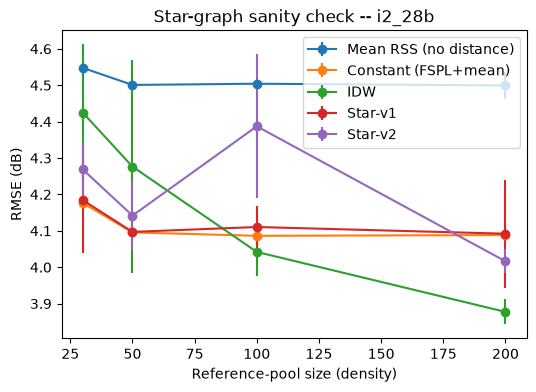

In [25]:
cmp_df = star_vs_baselines(SCENARIO_NAME, densities=(30, 50, 100, 200), K=8, n_seeds=3)
order = ["Mean RSS (no distance)", "Constant (FSPL+mean)", "IDW", "Star-v1", "Star-v2"]
cmp_summary = (cmp_df.groupby(["density", "method"])
                .agg(rmse_mean=("rmse", "mean"), rmse_std=("rmse", "std"),
                     mae_mean=("mae", "mean"), attn_entropy=("attn_entropy", "mean"))
                .reset_index())
display(cmp_summary.pivot(index="density", columns="method", values="rmse_mean")[order].round(3))
print("Normalised attention entropy (1.0 = uniform / not discriminating):")
display(cmp_summary[cmp_summary["method"].str.startswith("Star")]
        .pivot(index="density", columns="method", values="attn_entropy").round(3))

fig, ax = plt.subplots(figsize=(6, 4))
for m in order:
    g = cmp_summary[cmp_summary["method"] == m].sort_values("density")
    ax.errorbar(g["density"], g["rmse_mean"], yerr=g["rmse_std"], marker="o", label=m)
ax.set_xlabel("Reference-pool size (density)")
ax.set_ylabel("RMSE (dB)")
ax.set_title(f"Star-graph sanity check -- {SCENARIO_NAME}")
ax.legend()
plt.show()

### 9e. Run: random vs. k-means reference sampling across densities (v2)

Scenario "i2_28b" already exists in /home/praaneshnair/gitProjects/prism/deepmimo_scenarios
Subsampled i2_28b: 140901 -> 5000 rx points (at load time).
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 5000)


Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 46.11it/s]


[load_scenario] i2_28b: 9 node features [dist_to_tx, los_flag, dx, dy, dz, path_count, delay_spread, azimuth, elevation]


,density,strategy,rmse_mean,rmse_std,mae_mean,mae_std
0,30,kmeans,4.290544,0.186316,3.304644,0.182433
1,30,random,4.268699,0.072718,3.296635,0.196568
2,50,kmeans,4.362230,0.120960,3.324457,0.006278
3,50,random,4.141890,0.094491,3.231650,0.138591
4,100,kmeans,4.027029,0.062623,3.140166,0.002935
5,100,random,4.387229,0.198318,3.406371,0.112457
6,200,kmeans,4.028129,0.110164,3.137023,0.121566
7,200,random,4.016299,0.033142,3.102165,0.019492


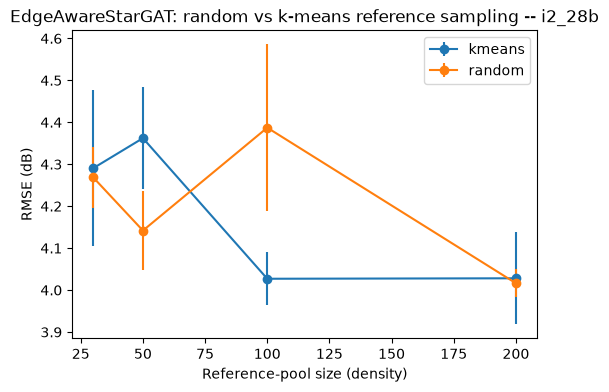

In [26]:
sampling_df = sampling_strategy_sweep(SCENARIO_NAME, densities=(30, 50, 100, 200), K=8, n_seeds=3, variant="v2")
sampling_summary = (sampling_df.groupby(["density", "strategy"])
                     .agg(rmse_mean=("rmse", "mean"), rmse_std=("rmse", "std"),
                          mae_mean=("mae", "mean"), mae_std=("mae", "std"))
                     .reset_index())
display(sampling_summary)

fig, ax = plt.subplots(figsize=(6, 4))
for strategy, grp in sampling_summary.groupby("strategy"):
    grp = grp.sort_values("density")
    ax.errorbar(grp["density"], grp["rmse_mean"], yerr=grp["rmse_std"], marker="o", label=strategy)
ax.set_xlabel("Reference-pool size (density)")
ax.set_ylabel("RMSE (dB)")
ax.set_title(f"EdgeAwareStarGAT: random vs k-means reference sampling -- {SCENARIO_NAME}")
ax.legend()
plt.show()

### 9f. (Optional) Run: K-reference sweep at fixed density (v2)

Scenario "i2_28b" already exists in /home/praaneshnair/gitProjects/prism/deepmimo_scenarios
Subsampled i2_28b: 140901 -> 5000 rx points (at load time).
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 5000)


Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 46.96it/s]


[load_scenario] i2_28b: 9 node features [dist_to_tx, los_flag, dx, dy, dz, path_count, delay_spread, azimuth, elevation]


,K,rmse_mean,rmse_std,mae_mean,mae_std
0,2,4.912183,0.578991,3.833134,0.552665
1,4,4.335624,0.220768,3.386967,0.231354
2,8,4.141890,0.094491,3.231650,0.138591
3,16,4.089107,0.053922,3.153895,0.093348
4,32,4.073255,0.099416,3.129101,0.021563


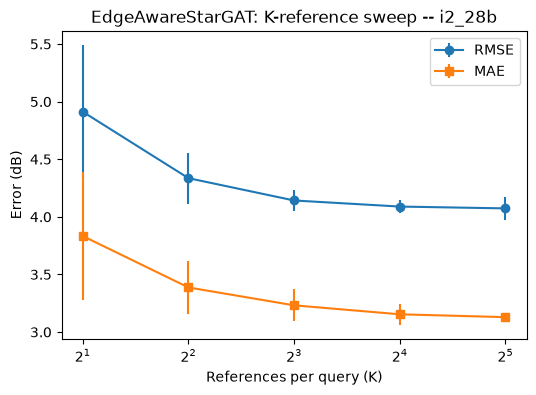

In [27]:
k_df = k_reference_sweep(SCENARIO_NAME, n_labeled=50, K_values=(2, 4, 8, 16, 32), n_seeds=3, variant="v2")
k_summary = (k_df.groupby("K")
              .agg(rmse_mean=("rmse", "mean"), rmse_std=("rmse", "std"),
                   mae_mean=("mae", "mean"), mae_std=("mae", "std"))
              .reset_index())
display(k_summary)

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(k_summary["K"], k_summary["rmse_mean"], yerr=k_summary["rmse_std"], marker="o", label="RMSE")
ax.errorbar(k_summary["K"], k_summary["mae_mean"], yerr=k_summary["mae_std"], marker="s", label="MAE")
ax.set_xscale("log", base=2)
ax.set_xlabel("References per query (K)")
ax.set_ylabel("Error (dB)")
ax.set_title(f"EdgeAwareStarGAT: K-reference sweep -- {SCENARIO_NAME}")
ax.legend()
plt.show()

end of file